In [1]:
# data 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import RFECV
import shap
import joblib
import umap
from sklearn.preprocessing import StandardScaler
le=LabelEncoder()
le_quad=LabelEncoder()

c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --models--
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV,LearningCurveDisplay,learning_curve,StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score,accuracy_score,roc_curve,auc
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix
from sklearn.base import clone
from hiclass import LocalClassifierPerParentNode


# pre-procces data


In [3]:
trainDf=pd.read_csv('train_60_custom_script.csv')
testDf=pd.read_csv('test_60_custom_script.csv')

quad_classes=['c_rd_na_1','c_rd_na_1_DoS','c_rp_na_1','c_rp_na_1_DoS']
train_quad_Df=trainDf[trainDf['Label'].isin(quad_classes)]
test_quad_Df=testDf[testDf['Label'].isin(quad_classes)]
X_train_quad=train_quad_Df.drop('Label',axis=1)
X_test_quad=test_quad_Df.drop('Label',axis=1)
le_quad.fit(train_quad_Df['Label'])
y_train_quad=le_quad.transform(train_quad_Df['Label'])
y_test_quad=le_quad.transform(test_quad_Df["Label"])
data_quad=pd.concat([train_quad_Df,test_quad_Df])
X_data_quad=data_quad.drop(['Label'],axis=1)
y_data_quad=le_quad.transform(data_quad["Label"])
trainDf['Label']=trainDf['Label'].replace(dict.fromkeys(quad_classes,'c_rd_rp_family'))
testDf['Label']=testDf['Label'].replace(dict.fromkeys(quad_classes,'c_rd_rp_family'))

le.fit(trainDf['Label'])
class_range=9
#drop the Labels from X_train/test and just keep the label on y_train/test
X_train=trainDf.drop('Label',axis=1)
y_train=le.transform(trainDf['Label'])
X_test=testDf.drop('Label',axis=1)
y_test=le.transform(testDf['Label'])
data=pd.concat([trainDf,testDf])
X_data=data.drop('Label',axis=1)
y_data=le.transform(data['Label'])


# Creating the models.

In [ ]:
#--XGBoost--
Xgb_model=XGBClassifier(
    n_estimators=100,
    n_jobs=-1,
    objective='multi:softprob',
    num_class=class_range,
    random_state=63,
    device="cuda"
)
#--Lgbm--
Lgbm_model=LGBMClassifier(
    learning_rate=0.05,
    device="gpu",
    boosting_type='gbdt',
    objective='multiclass',
    num_class=class_range,
    num_leaves=6,
    max_depth=10,
    random_state=63
)
#--CatBoost--
CatBoost_model=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=False,
    random_state=63,
    task_type="GPU",
)


In [4]:
#--XGBoost--
Xgb_model_quad=XGBClassifier(
    n_estimators=100,
    n_jobs=-1,
    objective='multi:softprob',
    num_class=4,
    random_state=63,
    device="cuda"
)
#--Lgbm--
Lgbm_model_quad=LGBMClassifier(
    learning_rate=0.05,
    device="gpu",
    boosting_type='gbdt',
    objective='multiclass',
    num_class=4,
    num_leaves=6,
    max_depth=10,
    random_state=63
)

In [ ]:
param_grid_Xgb={
    'n_estimators':[100,200,300],
    'max_depth':[4,5,6,7,8],
    'learning_rate':[0.05,0.1,0.3],
}

In [ ]:
grid_search_Xgb=GridSearchCV(
    estimator=Xgb_model,
    param_grid=param_grid_Xgb,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Xgb.fit(X_train,y_train)
print(f"best parameters= {grid_search_Xgb.best_params_}")
print(f'best cv score= {grid_search_Xgb.best_score_:.4f} ')

XGBOOST best parameters= {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
best cv score= 0.7387 

In [ ]:
grid_search_Xgb_quad=GridSearchCV(
    estimator=Xgb_model_quad,
    param_grid=param_grid_Xgb,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Xgb_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_Xgb_quad.best_params_}")
print(f'best cv score= {grid_search_Xgb_quad.best_score_:.4f} ')

Quad XGBOOST best parameters= {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
best cv score= 0.4456 

In [ ]:
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [15, 31, 63, 127], 
    'learning_rate': [0.05, 0.1, 0.3],      
}

In [ ]:
grid_search_Lgbm=GridSearchCV(
    estimator=Lgbm_model,
    param_grid=param_grid_lgbm,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Lgbm.fit(X_train,y_train)
print(f"best parameters= {grid_search_Lgbm.best_params_}")
print(f'best cv score= {grid_search_Lgbm.best_score_:.4f} ')

LightGBM best parameters= {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 15}
best cv score= 0.7314 

In [ ]:
grid_search_Lgbm_quad=GridSearchCV(
    estimator=Lgbm_model_quad,
    param_grid=param_grid_lgbm,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Lgbm_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_Lgbm_quad.best_params_}")
print(f'best cv score= {grid_search_Lgbm_quad.best_score_:.4f} ')


LGBM Quad best parameters= {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 15}
best cv score= 0.4417 

In [ ]:

param_grid_CatBoost= {
    'iterations': [100,200,300],
    'depth': [4,5,6,7,8],
    'learning_rate': [0.05, 0.1,0.3]
}

In [5]:
CatBoost_model=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    random_state=63,
    task_type="GPU",
    verbose=0,
    allow_writing_files=False
)

In [ ]:
grid_search_CatBoost=GridSearchCV(
    estimator=CatBoost_model,
    param_grid=param_grid_CatBoost,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_CatBoost.fit(X_train,y_train)
print(f"best parameters= {grid_search_CatBoost.best_params_}")
print(f'best cv score= {grid_search_CatBoost.best_score_:.4f} ')

CatBoost best parameters= {'depth': 8, 'iterations': 100, 'learning_rate': 0.05}
best cv score= 0.7390 

In [6]:
CatBoost_model_testing=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=False,
    random_state=63,
    task_type="GPU",
    allow_writing_files=False
)


In [ ]:
grid_search_CatBoost_quad=GridSearchCV(
    estimator=CatBoost_model_testing,
    param_grid=param_grid_CatBoost,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_CatBoost_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_CatBoost_quad.best_params_}")
print(f'best cv score= {grid_search_CatBoost_quad.best_score_:.4f} ')

CatBoost quad best parameters= {'depth': 4, 'iterations': 300, 'learning_rate': 0.1}
best cv score= 0.4567 

In [ ]:
Xgb_model=grid_search_Xgb.best_estimator_
Lgbm_model=grid_search_Lgbm.best_estimator_
CatBoost_model=grid_search_CatBoost.best_estimator_

In [ ]:
Xgb_model_quad=grid_search_Xgb_quad.best_estimator_
Lgbm_model_quad=grid_search_Lgbm_quad.best_estimator_


# feature selection:


In [ ]:
rfecv_Lgbm=RFECV(
    estimator=Lgbm_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
    verbose=0
)
rfecv_Lgbm.fit(X_train,y_train)
print(f'selected features: {rfecv_Lgbm.n_features_}')

LightGBM selected features: 46

In [ ]:
rfecv_Lgbm_quad=RFECV(
    estimator=Lgbm_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Lgbm_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_Lgbm_quad.n_features_}')

Light GBM QUAD selected features: 61

In [ ]:
rfecv_Xgb=RFECV(
    estimator=Xgb_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Xgb.fit(X_train,y_train)
print(f'selected features: {rfecv_Xgb.n_features_}')


XGBOOST selected features: 26

In [ ]:
rfecv_Xgb_quad=RFECV(
    estimator=Xgb_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Xgb_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_Xgb_quad.n_features_}')


XGB quad selected features: 26


In [ ]:
rfecv_CatBoost=RFECV(
    estimator=CatBoost_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_CatBoost.fit(X_train,y_train)

print(f'selected features: {rfecv_CatBoost.n_features_}')

CatBoost selected features: 56


In [ ]:
Catboost_model_quad = grid_search_CatBoost_quad.best_estimator_

In [ ]:
rfecv_CatBoost_quad=RFECV(
    estimator=Catboost_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_CatBoost_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_CatBoost_quad.n_features_}')

CatBoost quad selected features: 106


Used Joblib to load the results and not running again Recursive feature elimination with cross-validation and grid search to find selected features and best parameters for the models 

In [ ]:
joblib.dump(Catboost_model_quad,'CatBoost_model_quad.pkl')

In [ ]:
joblib.dump(rfecv_Xgb,'rfecv_Xgb.pkl')
joblib.dump(rfecv_Lgbm, 'rfecv_Lgbm.pkl')
joblib.dump(rfecv_CatBoost, 'rfecv_CatBoost.pkl')
joblib.dump(Xgb_model,'Xgb_model.pkl')
joblib.dump(Lgbm_model,'Lgbm_model.pkl')
joblib.dump(CatBoost_model,'CatBoost_model.pkl')
joblib.dump (Xgb_model_quad,'Xgb_model_quad.pkl')
joblib.dump(Lgbm_model_quad,'Lgbm_model_quad.pkl')
joblib.dump(rfecv_Xgb_quad,'rfecv_Xgb_quad.pkl')
joblib.dump(rfecv_Lgbm_quad,'rfecv_Lgbm_quad.pkl')
joblib.dump(rfecv_CatBoost_quad,'rfecv_CatBoost_quad.pkl')


In [7]:
rfecv_Xgb=joblib.load('rfecv_Xgb.pkl')
rfecv_Lgbm = joblib.load('rfecv_Lgbm.pkl')
rfecv_CatBoost=joblib.load('rfecv_CatBoost.pkl')
Xgb_model=joblib.load('Xgb_model.pkl')
Lgbm_model=joblib.load('Lgbm_model.pkl')
CatBoost_model=joblib.load('CatBoost_model.pkl')
rfecv_Xgb_quad=joblib.load('rfecv_Xgb_quad.pkl')
rfecv_Lgbm_quad=joblib.load('rfecv_Lgbm_quad.pkl')
rfecv_CatBoost_quad=joblib.load('rfecv_CatBoost_quad.pkl')
Xgb_model_quad=joblib.load('Xgb_model_quad.pkl')
Lgbm_model_quad=joblib.load('Lgbm_model_quad.pkl')
Catboost_model_quad=joblib.load('CatBoost_model_quad.pkl') 

X_train_Feature_Selection_Xgb=X_train.loc[:,rfecv_Xgb.support_]
X_train_Feature_Selection_Lgbm= X_train.loc[:,rfecv_Lgbm.support_]
X_train_Feature_Selection_CatBoost=X_train.loc[:,rfecv_CatBoost.support_]



X_test_Feature_Selection_Xgb=X_test.loc[:,rfecv_Xgb.support_]
X_test_Feature_Selection_Lgbm= X_test.loc[:,rfecv_Lgbm.support_]
X_test_Feature_Selection_CatBoost=X_test.loc[:,rfecv_CatBoost.support_]


X_train_Feature_Selection_Xgb_quad = X_train_quad.loc[:, rfecv_Xgb_quad.support_]
X_train_Feature_Selection_Lgbm_quad = X_train_quad.loc[:, rfecv_Lgbm_quad.support_]
X_train_Feature_Selection_CatBoost_quad = X_train_quad.loc[:, rfecv_CatBoost_quad.support_]

X_test_Feature_Selection_Xgb_quad = X_test_quad.loc[:, rfecv_Xgb_quad.support_]
X_test_Feature_Selection_Lgbm_quad = X_test_quad.loc[:, rfecv_Lgbm_quad.support_]
X_test_Feature_Selection_CatBoost_quad = X_test_quad.loc[:, rfecv_CatBoost_quad.support_]



# Finding Feature importances and creating a model based only on those features.
#### plotting feature importance in horizontal bar chart with feature selection and all features 

In [8]:
models = [
    (Xgb_model, X_test, "XGBoost"),
    (rfecv_Xgb.estimator_, X_test_Feature_Selection_Xgb, "XGBoost FS"),
    (Xgb_model_quad,X_test_quad,"XGBOOST QUAD"),
    (rfecv_Xgb_quad.estimator_,X_test_Feature_Selection_Xgb_quad,"XGBOOST QUAD FS"),
    (Lgbm_model, X_test, "LightGBM"),
    (rfecv_Lgbm.estimator_, X_test_Feature_Selection_Lgbm, "LightGBM FS"),
    (Lgbm_model_quad,X_test_quad,"LightGBM QUAD"),
    (rfecv_Lgbm_quad.estimator_,X_test_Feature_Selection_Lgbm_quad,"LightGBM QUAD FS"),
    (CatBoost_model, X_test, "CatBoost"),
    (rfecv_CatBoost.estimator_, X_test_Feature_Selection_CatBoost, "CatBoost FS"),
    (Catboost_model_quad,X_test_quad,'CatBoost QUAD'),
    (rfecv_CatBoost_quad.estimator_,X_test_Feature_Selection_CatBoost_quad,"CatBoost QUAD FS ")
]

In [14]:
def functions(function):
    for model,X,title in models:
        function(model,X,title)

c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\core.py:553: UserWarning: [17:55:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


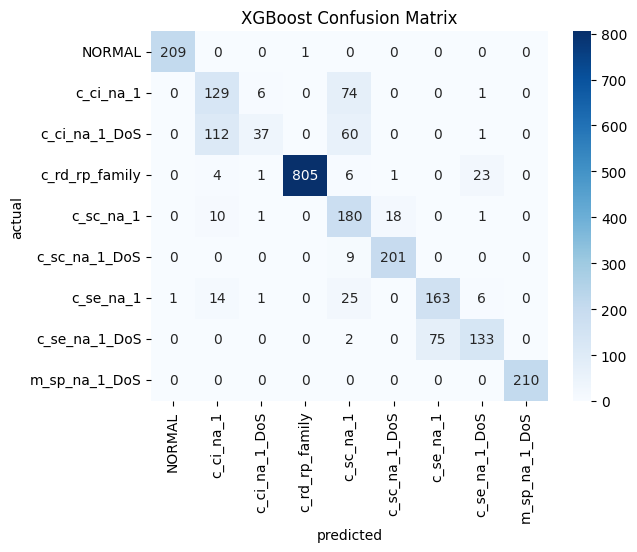

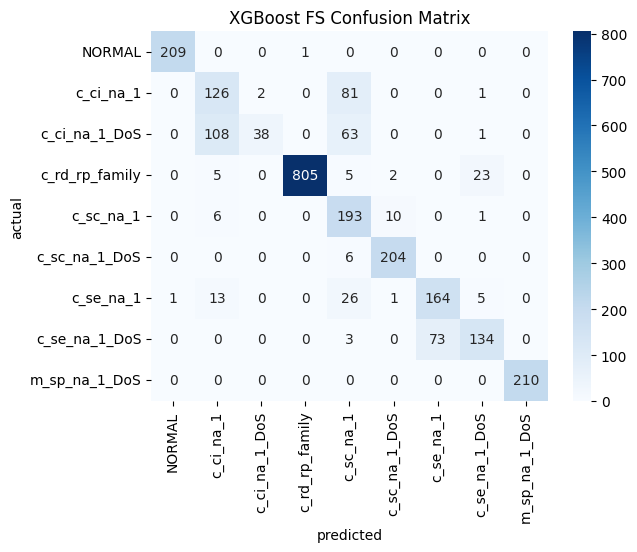

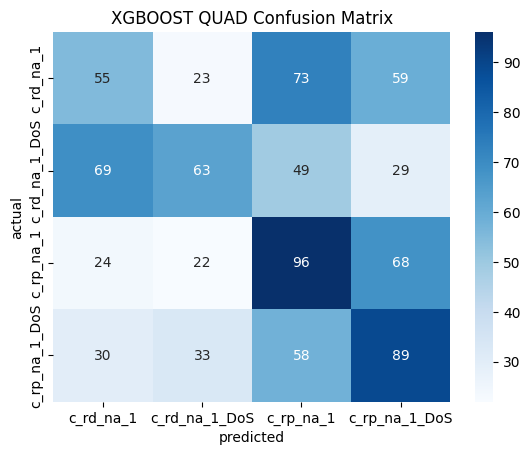

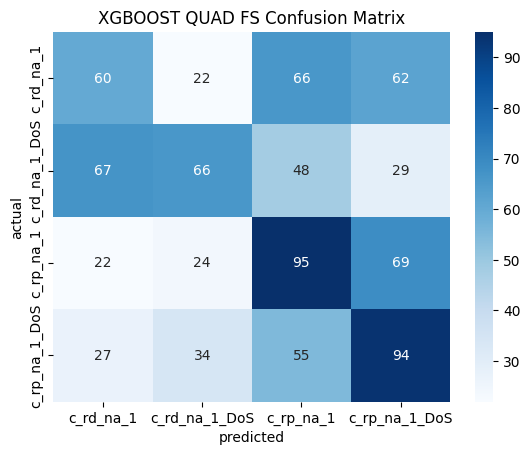

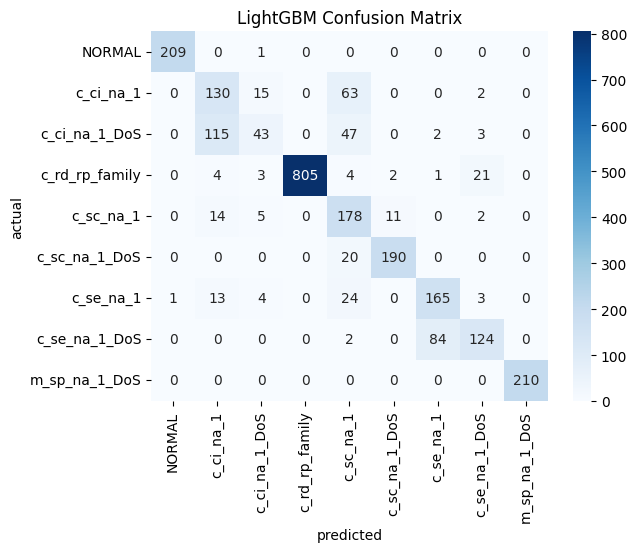

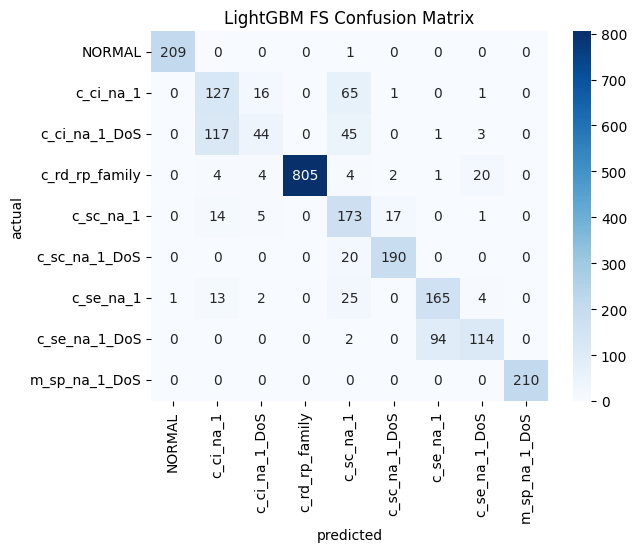

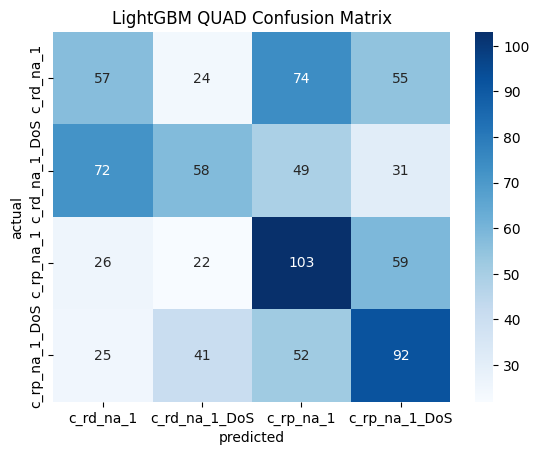

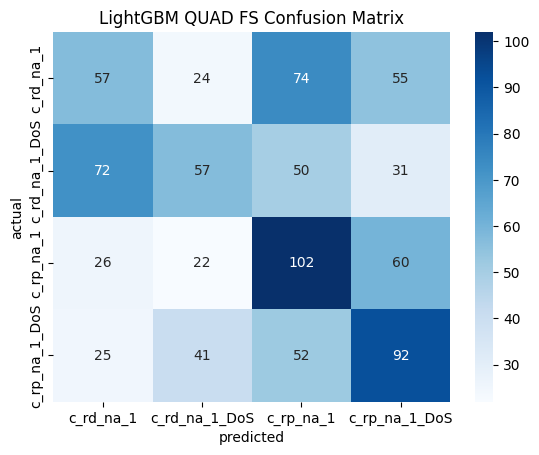

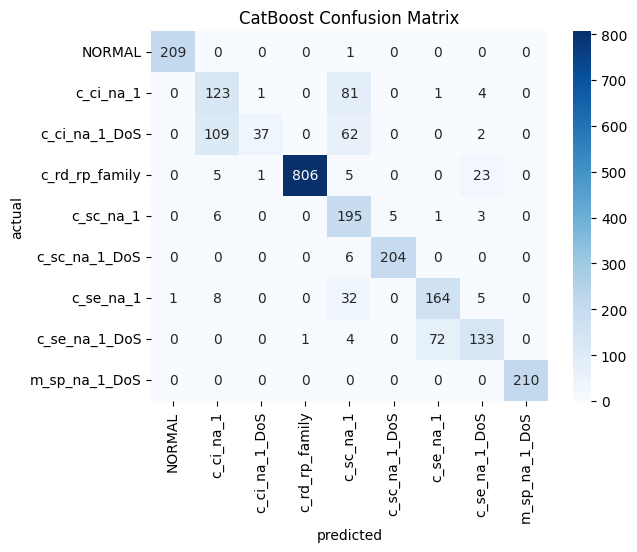

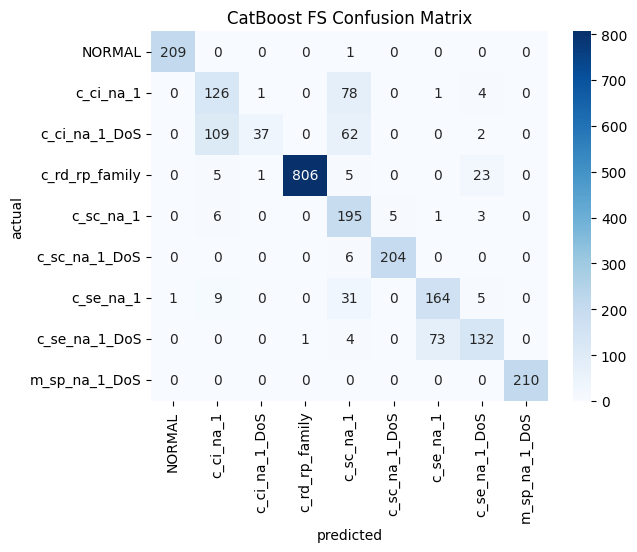

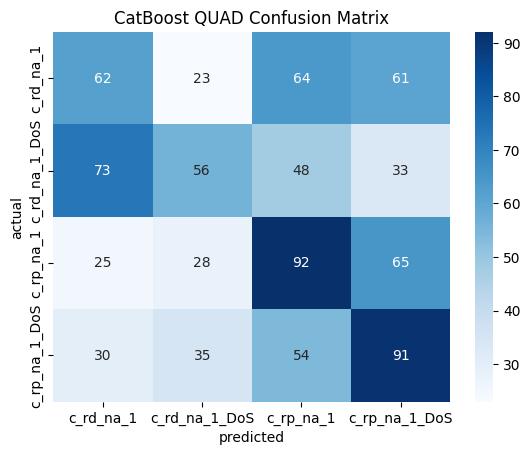

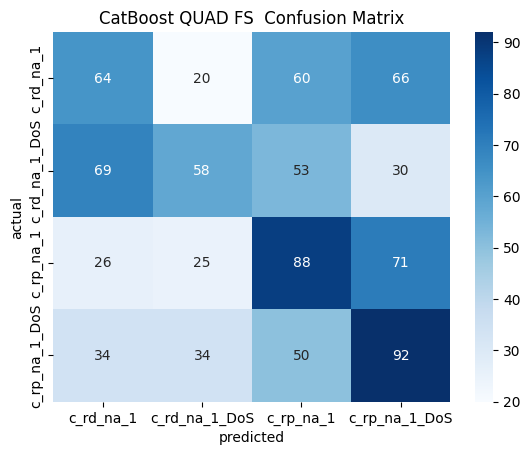

In [15]:
def confusion_matrixes(model,X,title,):
    if 'QUAD' in title:
        confusion_matrix_model=confusion_matrix(y_test_quad,model.predict(X))
        sns.heatmap(confusion_matrix_model,annot=True,fmt='d',cmap='Blues',xticklabels=le_quad.classes_,yticklabels=le_quad.classes_)
        plt.xlabel('predicted')
        plt.ylabel('actual')
        plt.title(title+' Confusion Matrix')
        plt.show()
        
    else : 
        confusion_matrix_model=confusion_matrix(y_test,model.predict(X))
        sns.heatmap(confusion_matrix_model,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_)
        plt.xlabel('predicted')
        plt.ylabel('actual')
        plt.title(title+' Confusion Matrix')
        plt.show()
    return 
functions(confusion_matrixes)

### Confusion matrix
 
In the full models, there is a small confusion between base classes and their DoS counterparts.
 
In the quad models, every class is confused with every other one — which makes sense, since c_rd_na_1, c_rd_na_1_DoS, c_rp_na_1 and c_rp_na_1_DoS have very similar characteristics. c_rd_na_1 requests a specific information object from a device (a read command), while c_rp_na_1 restarts the device's processes or counter values (a reset command).

The other classes separate more easily because their behaviour is more distinctive — for example, sending an ON/OFF command (c_sc_na_1) or setting a set-point (an arithmetic value) on a device (c_se_na_1).


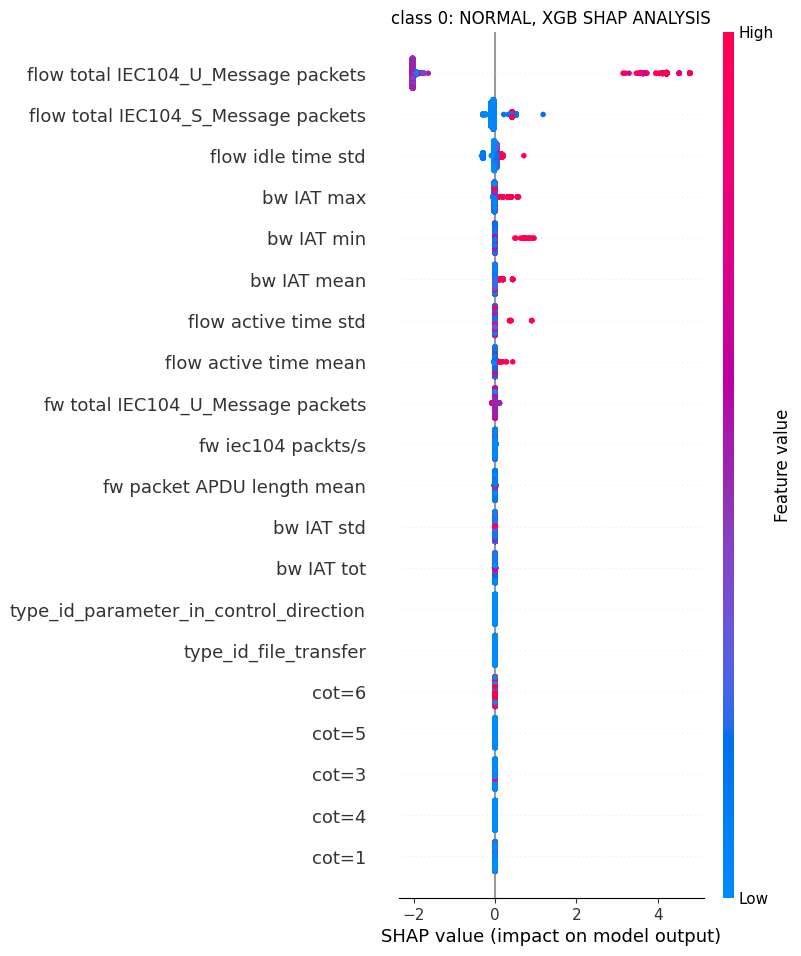

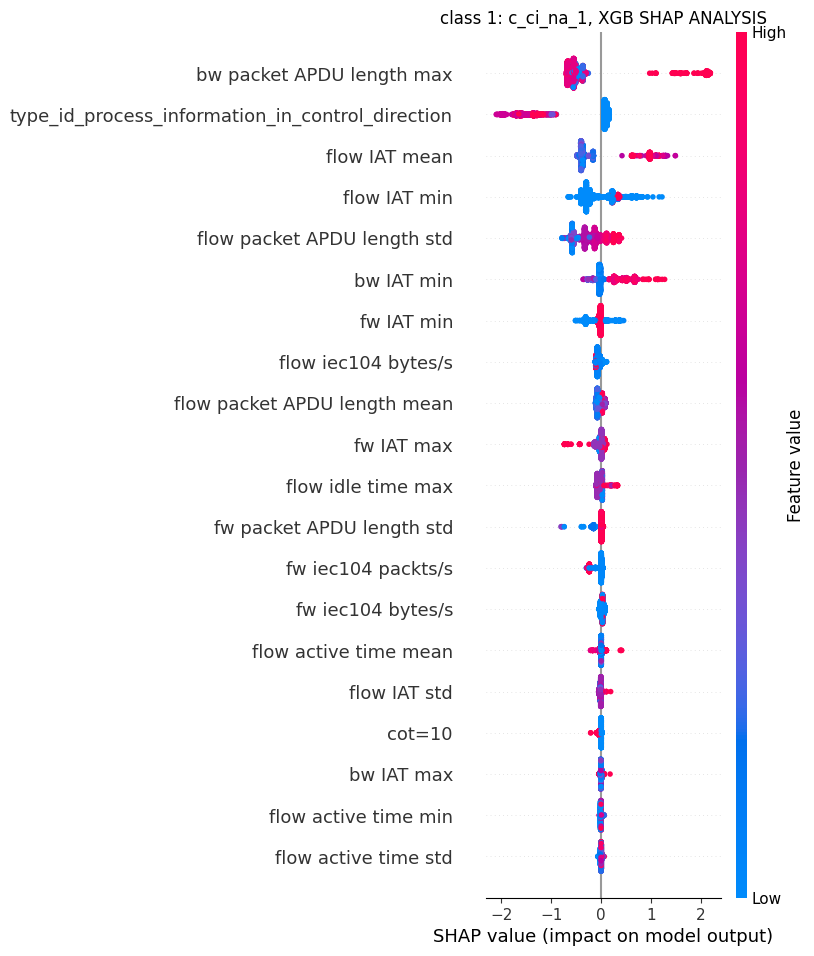

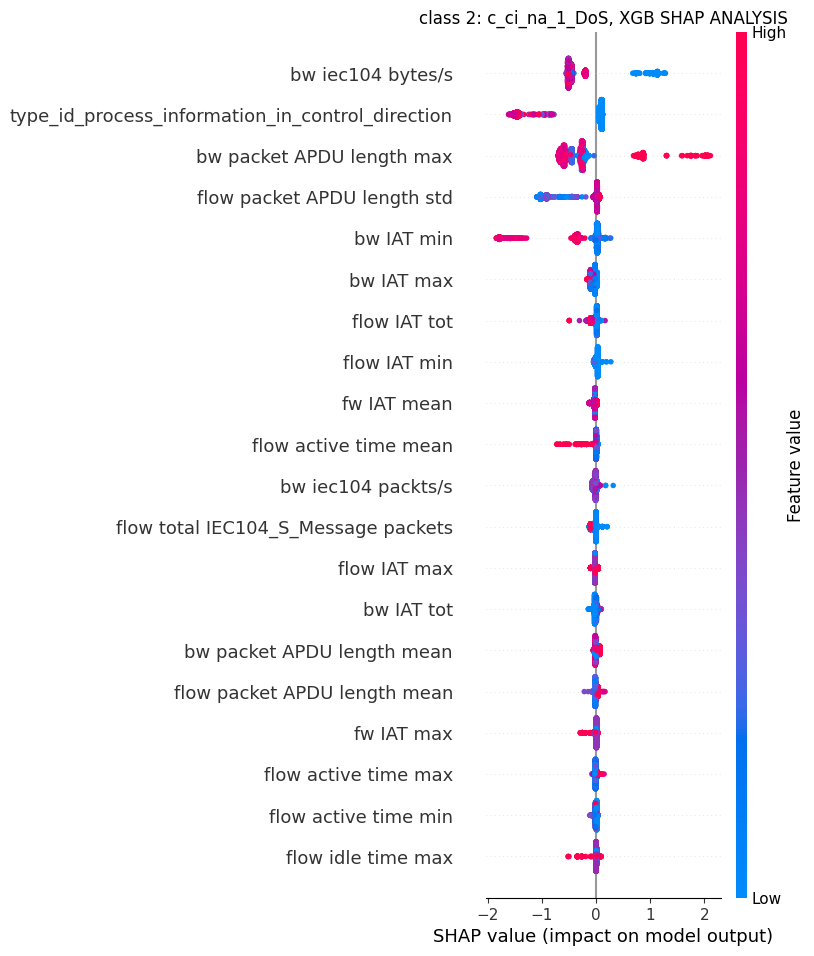

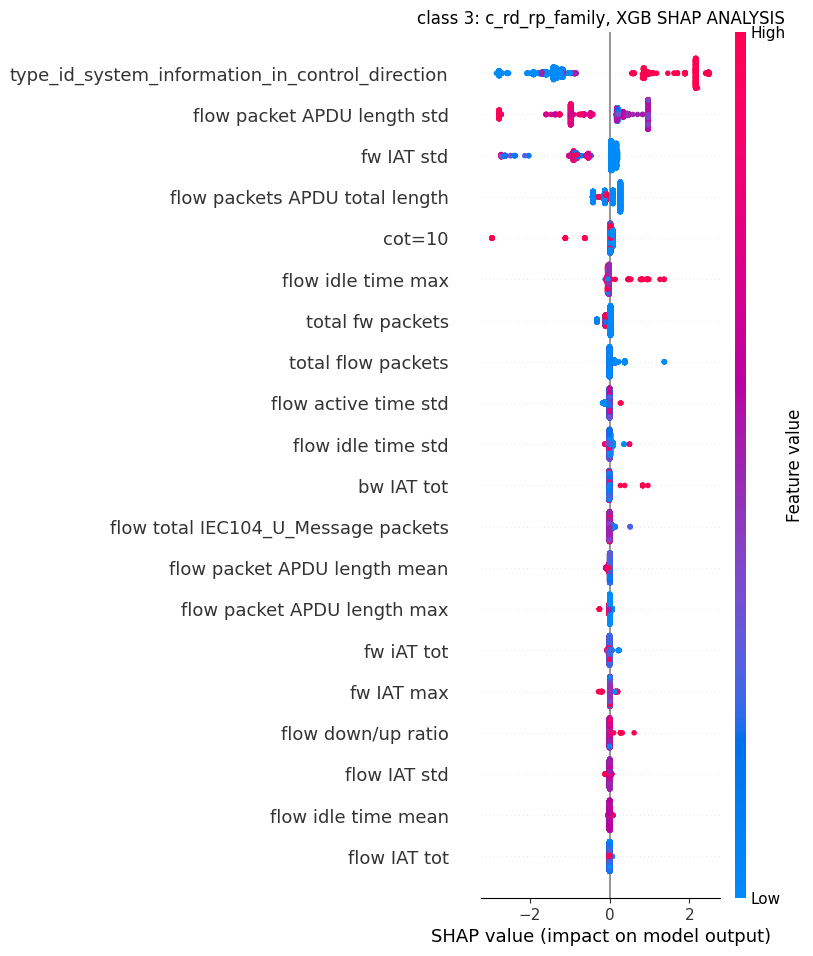

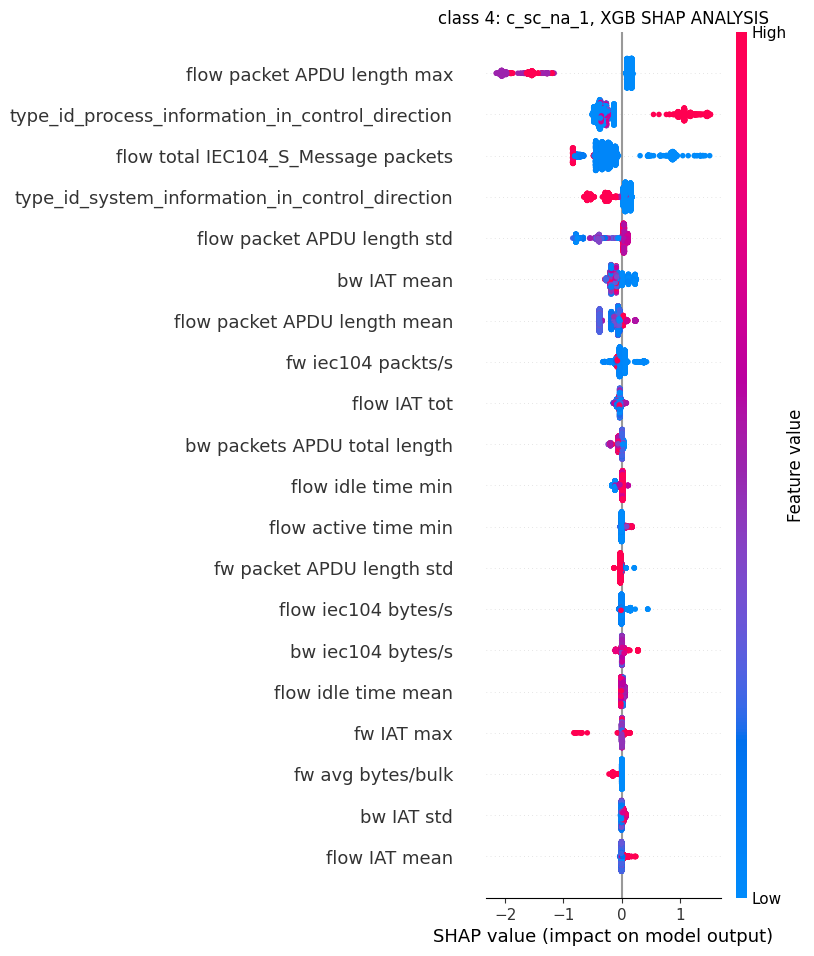

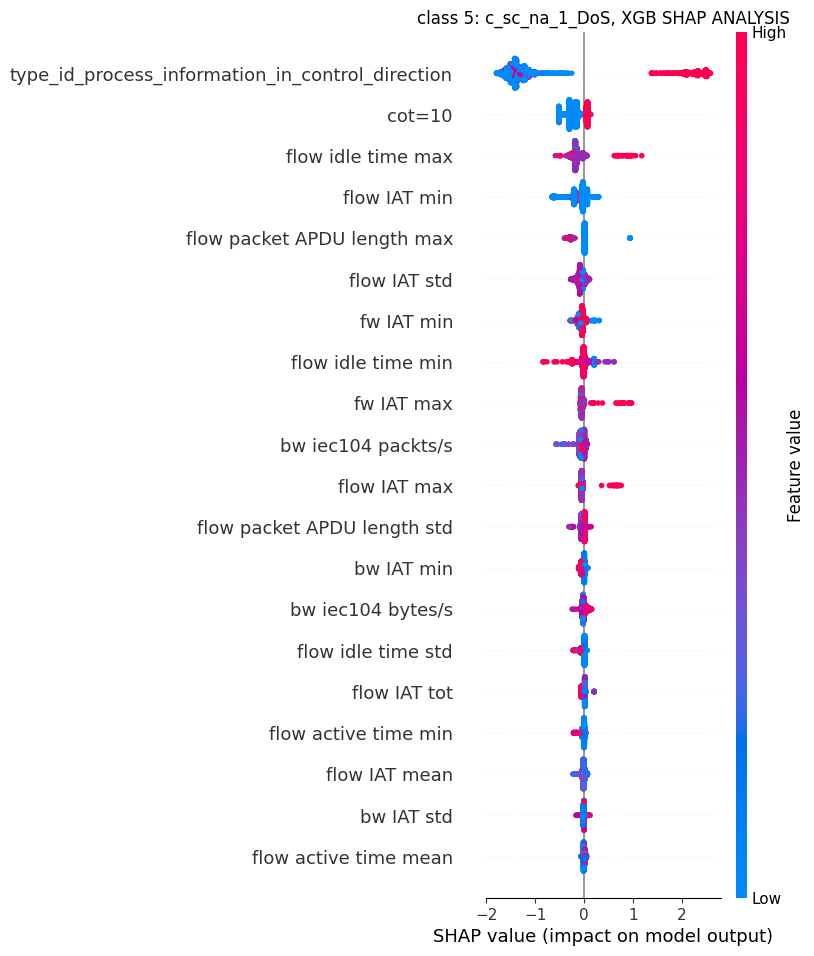

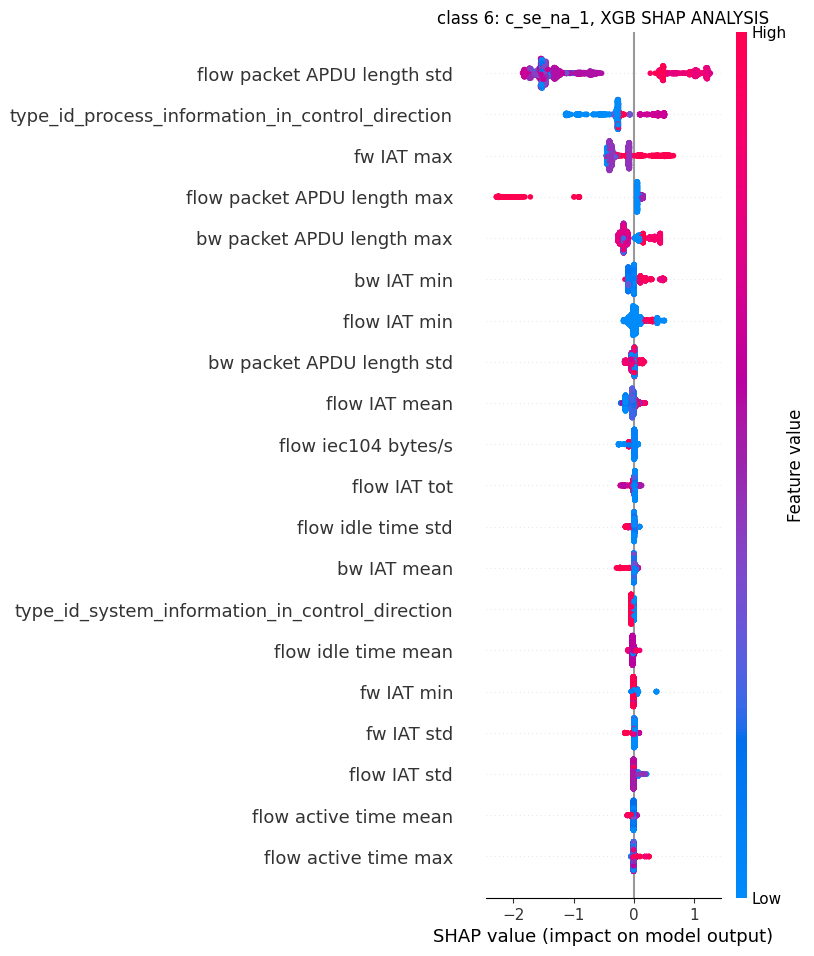

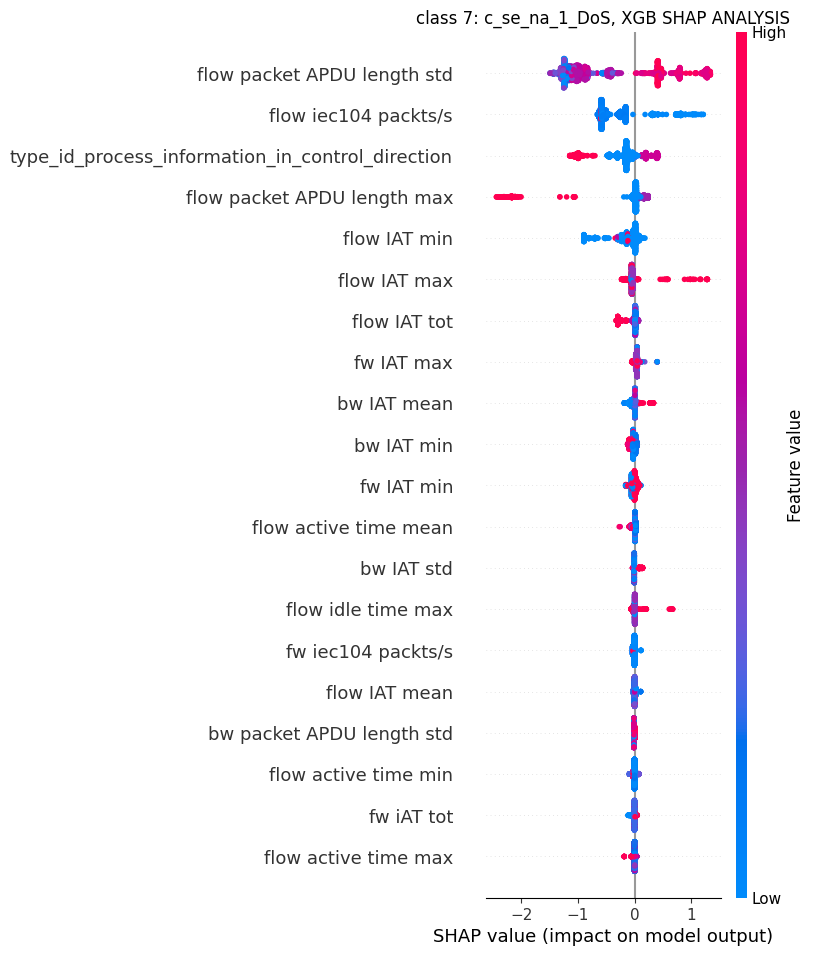

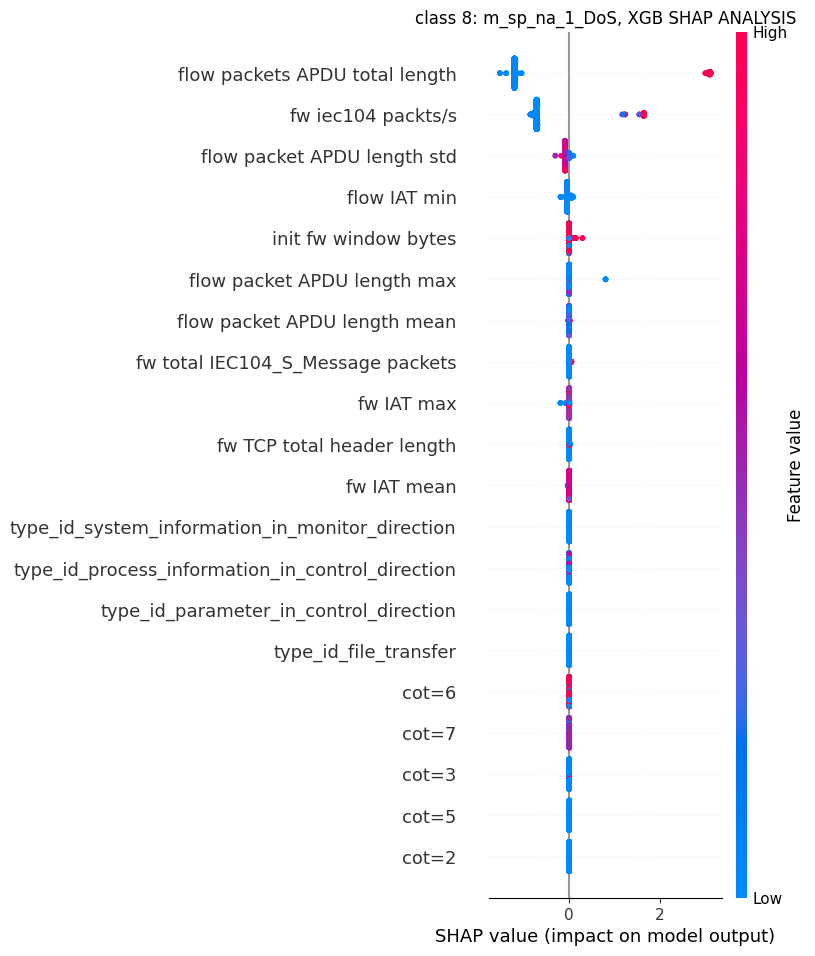

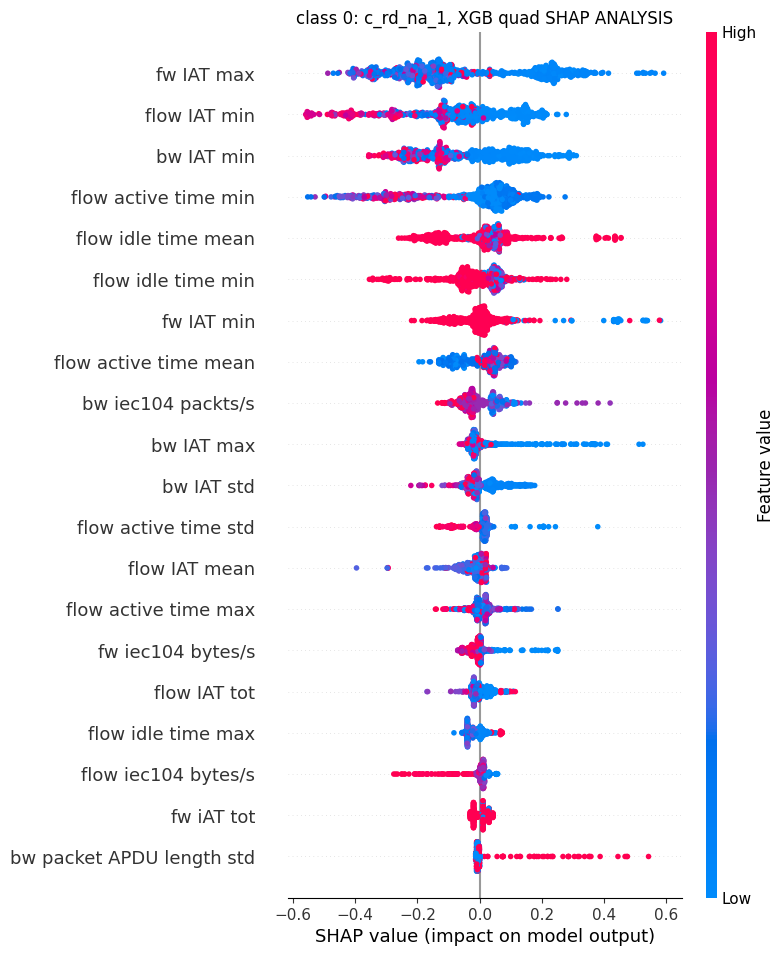

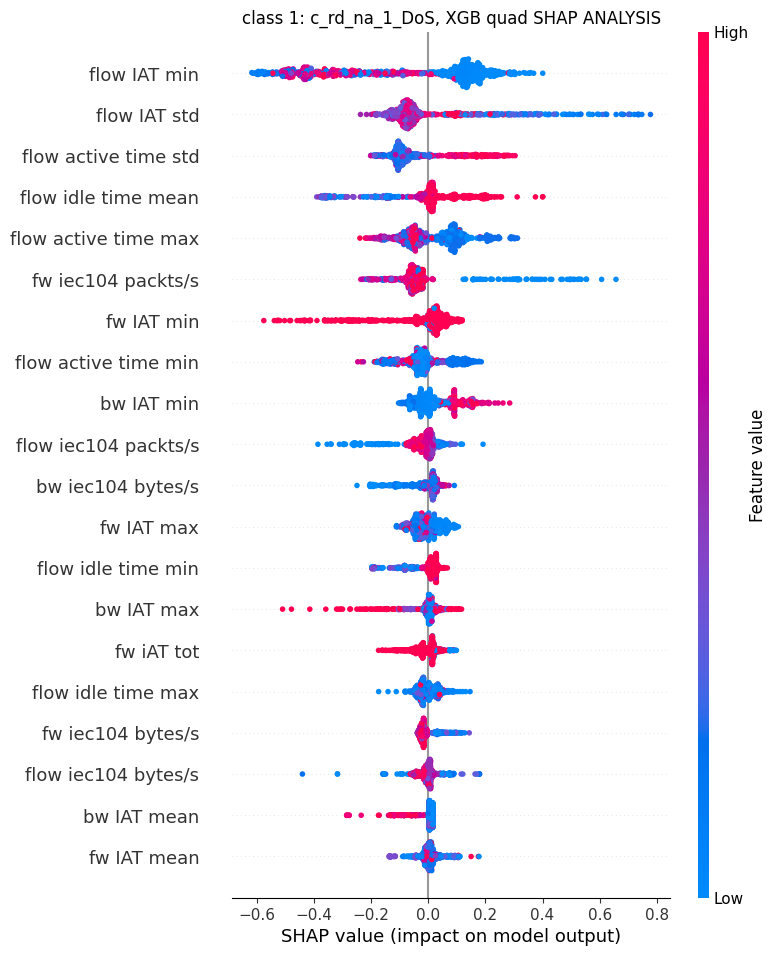

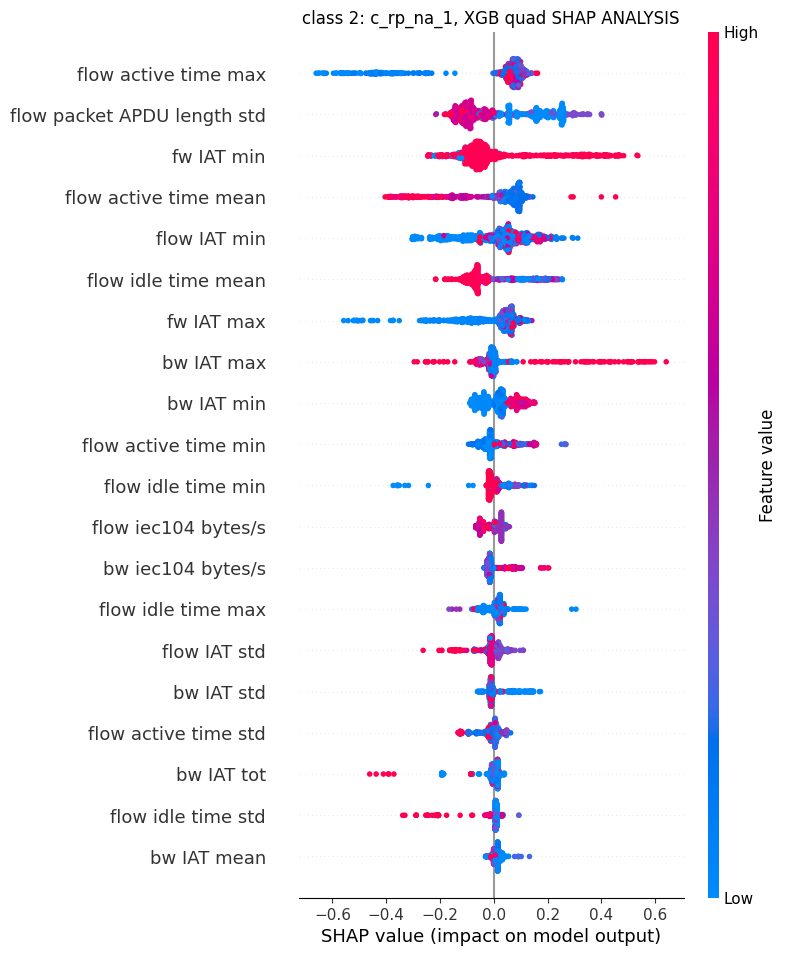

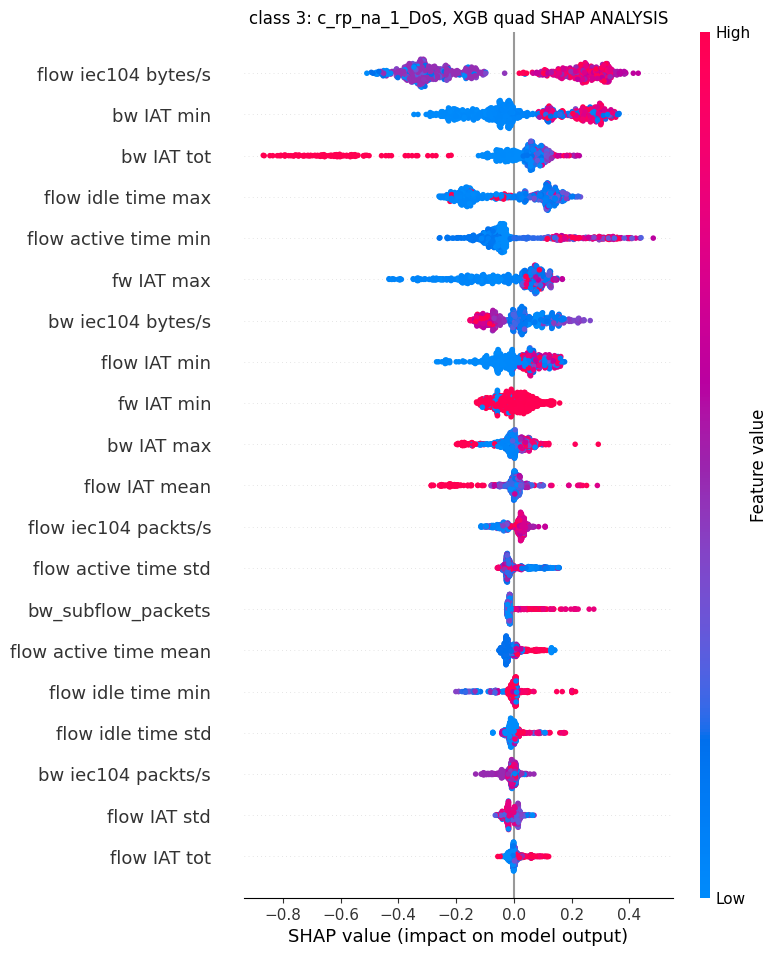

In [16]:
def Shap_(model,X_test,title):
    shap_explenation=shap.TreeExplainer(model)
    shap_values=shap_explenation.shap_values(X_test)
    shap_classes={c:shap_values[:,:,c] for c in range(class_range)}
    for i in range(class_range):
        shap.summary_plot(shap_classes[i],X_test,show=False)
        plt.title(f'class {i}: {le.classes_[i]}, {title}')
        plt.show()

def Shap_quad(model,X_test,title):
    shap_explenation=shap.TreeExplainer(model)
    shap_values=shap_explenation.shap_values(X_test)
    shap_classes={c:shap_values[:,:,c] for c in range(4)}
    for i in range(4):
        shap.summary_plot(shap_classes[i],X_test,show=False)
        plt.title(f'class {i}: {le_quad.classes_[i]}, {title}')
        plt.show()
Shap_(Xgb_model,X_test,"XGB SHAP ANALYSIS")

Shap_quad(Xgb_model_quad,X_test_quad,"XGB quad SHAP ANALYSIS")

# SHAP — most influential feature per class

### normal — flow total iec104_U_Message packets has the highest SHAP value, which makes sense since this feature is built from normal traffic.

### c_ci_na_1 — Bw packet APDU length max has the highest SHAP value, marking it as the defining feature for this class.

### c_ci_na_1_DoS — bw iec104 bytes and type_id_process_information_in_control_direction have the strongest negative SHAP values, pushing the model away from this class.

### c_rd_rp_family — type_id_system_information_in_control_direction has a positive SHAP value (pushing toward this class), while flow packet APDU length std has a negative one (pushing away) — which makes sense since these classes have small size.

### c_sc_na_1 — flow packet APDU length max has a negative SHAP value for this class.

### c_sc_na_1_DoS — type_id_information_in_control_direction has a large positive SHAP value, helping the model recognize this class.

### m_sp_na_1_DoS — flow packet APDU and fw iec104 packets/s have positive SHAP values that help the model recognize this class, which makes sense since this protocol carries big data.

### Quad family — the SHAP values for each class *are very small* (roughly −0.6 to 0.6), which makes these classes very hard for the models to separate.

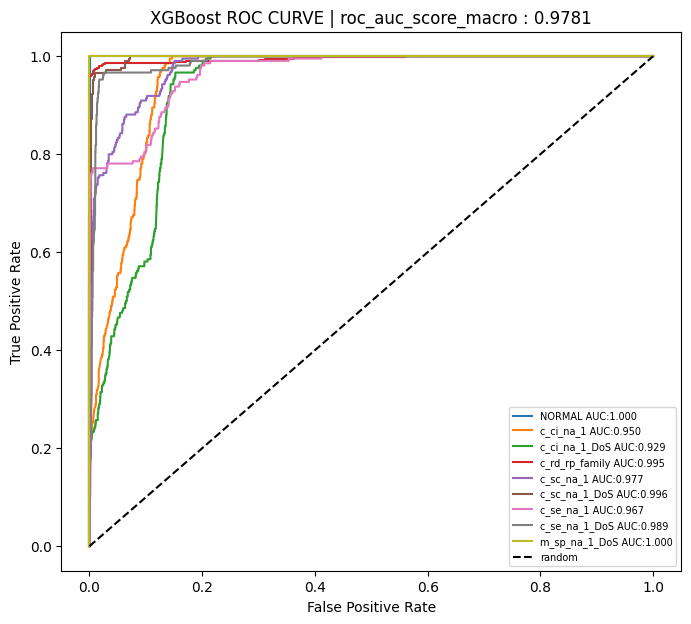

0.9780771647884742


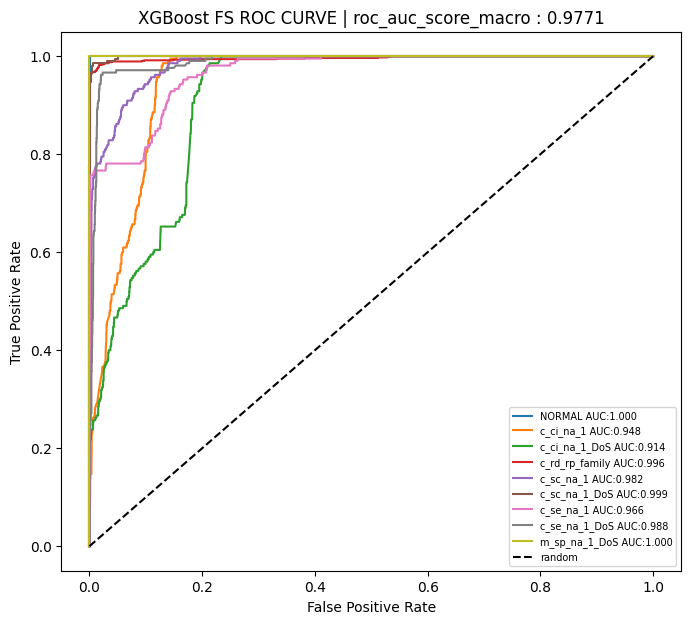

0.9771071077841912


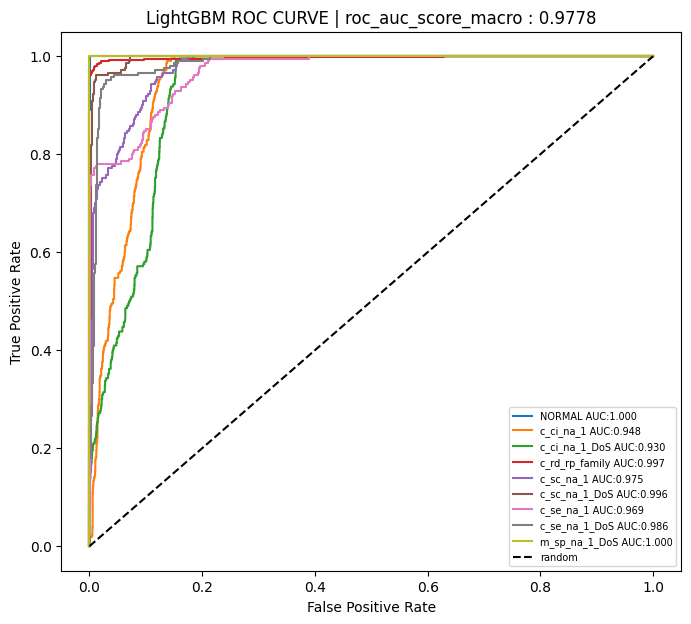

0.9778432854623331


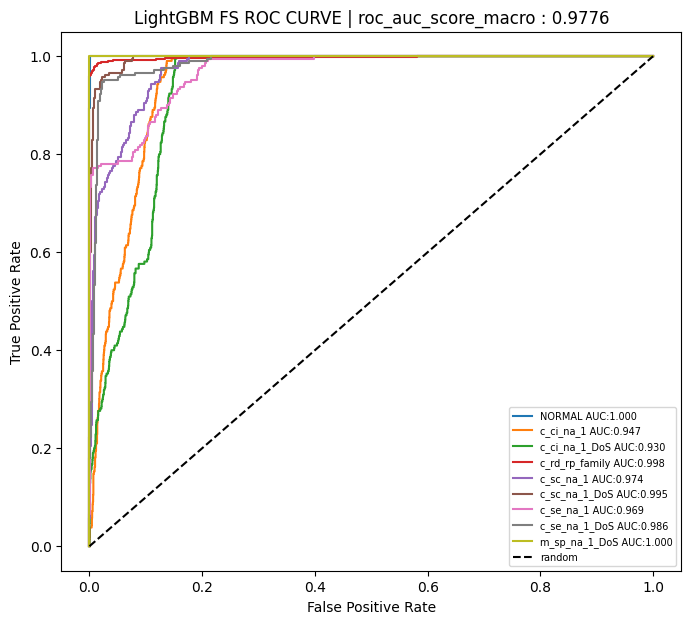

0.9775780766852196


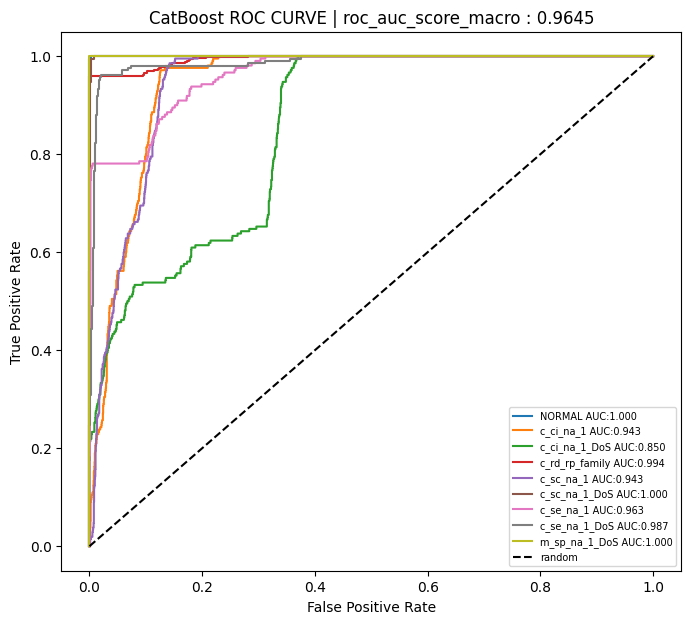

0.9644956151652581


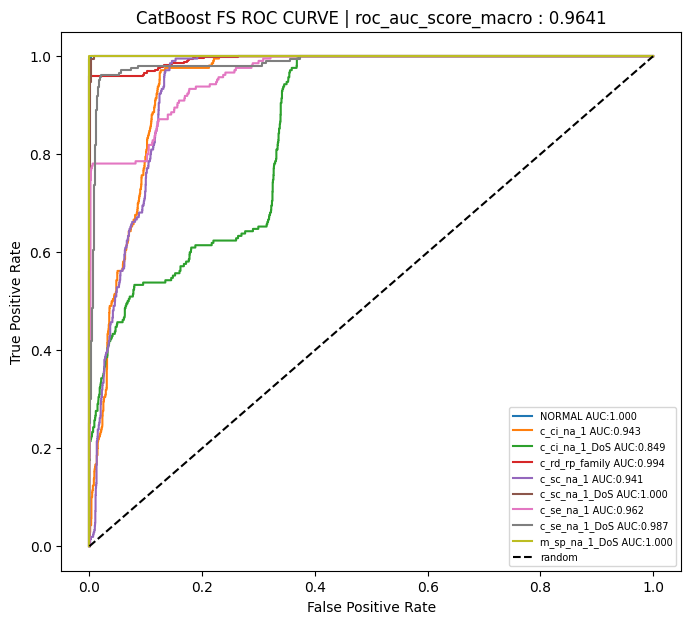

0.9640858127762889


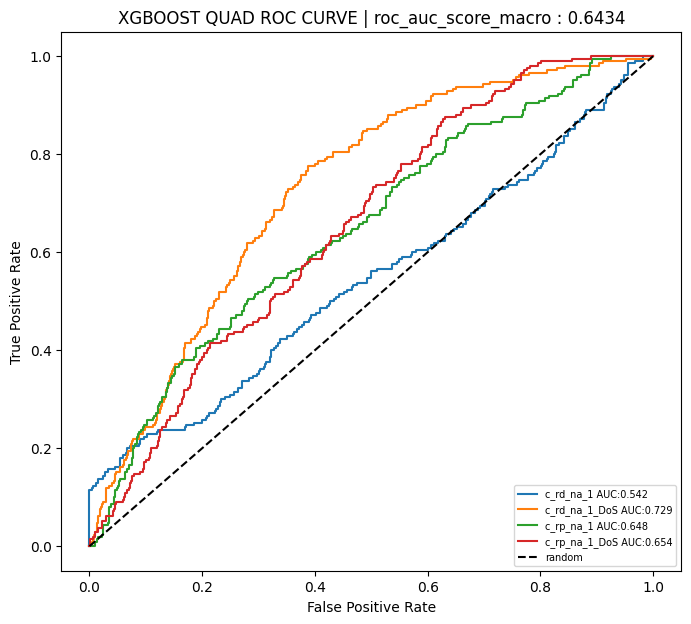

0.6434126984126984


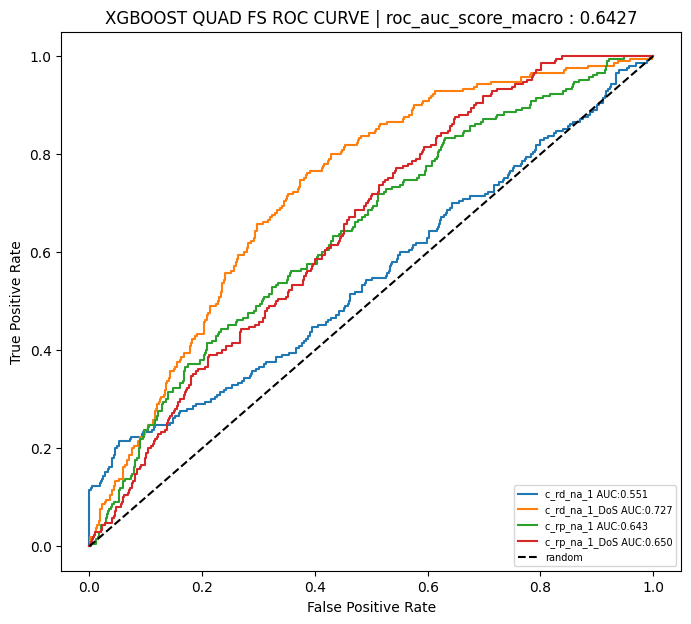

0.6427191987906273


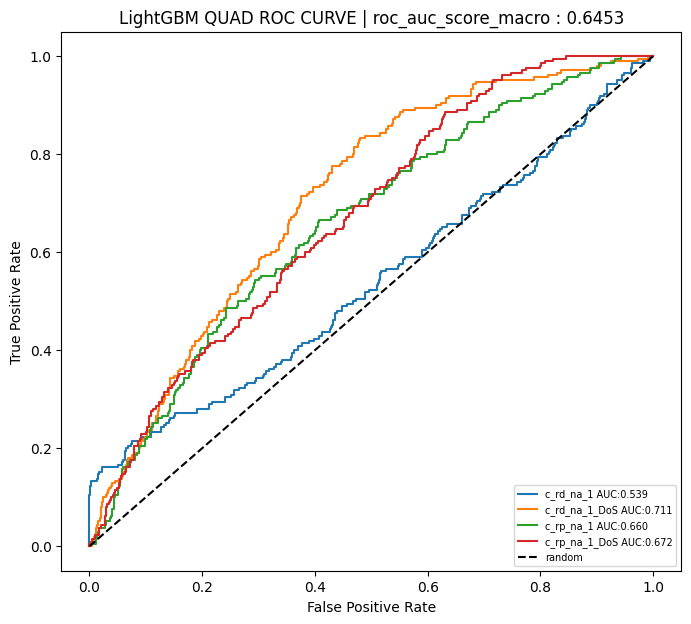

0.6452947845804989


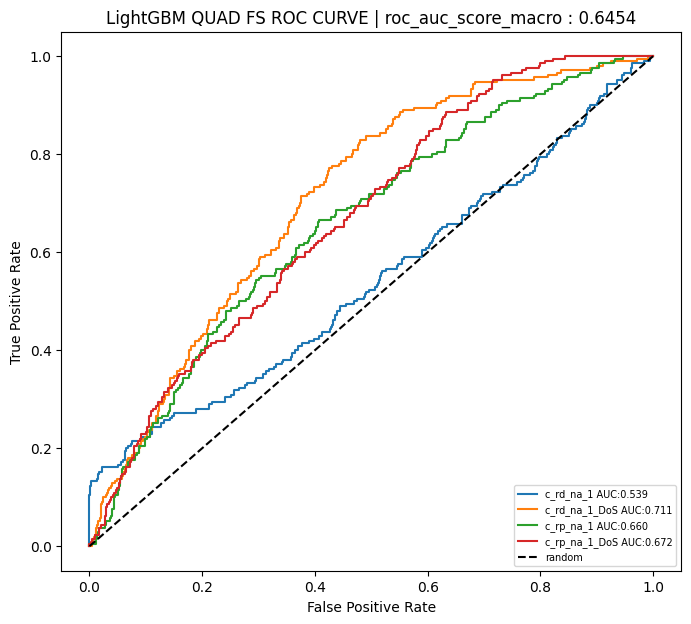

0.6454195011337869


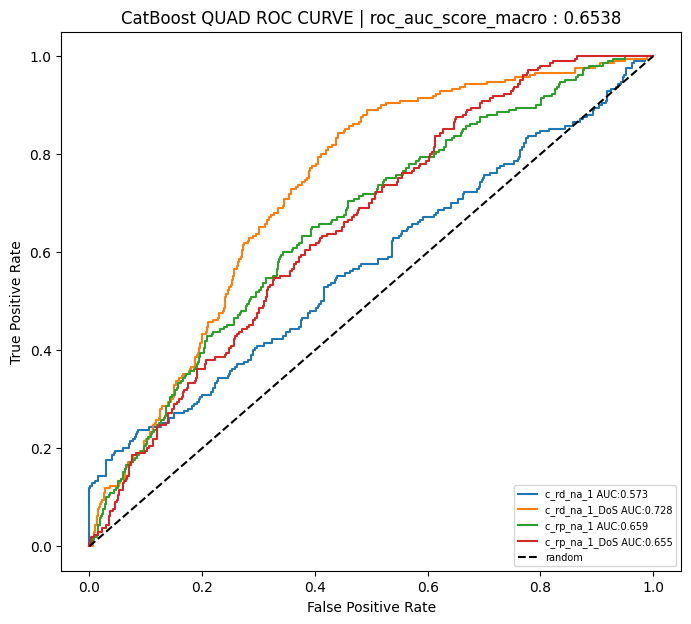

0.653843537414966


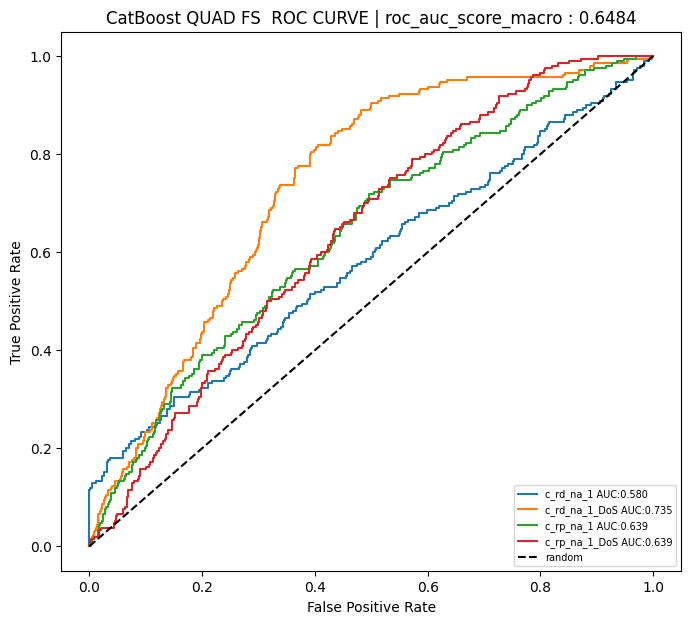

0.6484051398337112


In [17]:
Binarized_labels=label_binarize(y_test,classes=range(len(le.classes_)))
Binarized_labels_quad = label_binarize(y_test_quad, classes=range(len(le_quad.classes_)))
def roc_curve_auc(model,X,title):
    if "QUAD" in title:
        return 
    model_fpr = {}
    model_tpr = {}
    model_y_pred_proba=model.predict_proba(X)
    for i in range(class_range):
        model_fpr[i],model_tpr[i],_=roc_curve(Binarized_labels[:,i],model_y_pred_proba[:,i])
    model_auc=roc_auc_score(y_test,model_y_pred_proba,multi_class='ovr',average='macro')
    plt.figure(figsize=(8,7))
    for i in range(class_range):
        model_roc_auc=auc(model_fpr[i],model_tpr[i])
        plt.plot(model_fpr[i],model_tpr[i],label=f'{le.classes_[i]} AUC:{model_roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--',label='random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right',fontsize=7)
    plt.title(f'{title} ROC CURVE | roc_auc_score_macro : {model_auc:.4f}')
    plt.show()
    print(model_auc)

functions(roc_curve_auc)


def roc_curve_auc_quad(model,X,title):
    if "QUAD" not in title:
        return
    model_fpr = {}
    model_tpr = {}
    model_y_pred_proba=model.predict_proba(X)
    for i in range(4):
        model_fpr[i],model_tpr[i],_=roc_curve(Binarized_labels_quad[:,i],model_y_pred_proba[:,i])
    model_auc=roc_auc_score(y_test_quad,model_y_pred_proba,multi_class='ovr',average='macro')
    plt.figure(figsize=(8,7))
    for i in range(4):
        model_roc_auc=auc(model_fpr[i],model_tpr[i])
        plt.plot(model_fpr[i],model_tpr[i],label=f'{le_quad.classes_[i]} AUC:{model_roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--',label='random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right',fontsize=7)
    plt.title(f'{title} ROC CURVE | roc_auc_score_macro : {model_auc:.4f}')
    plt.show()
    print(model_auc)
    
functions(roc_curve_auc_quad) 

ROC curves
The full-class models reach good ROC-AUC scores, but the quad models predict near random (≈0.5).

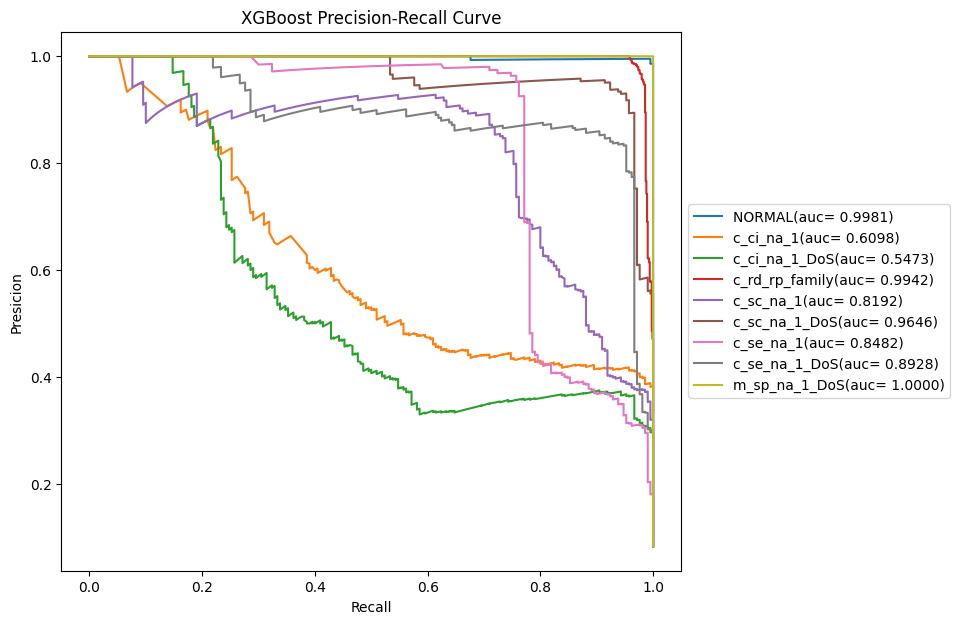

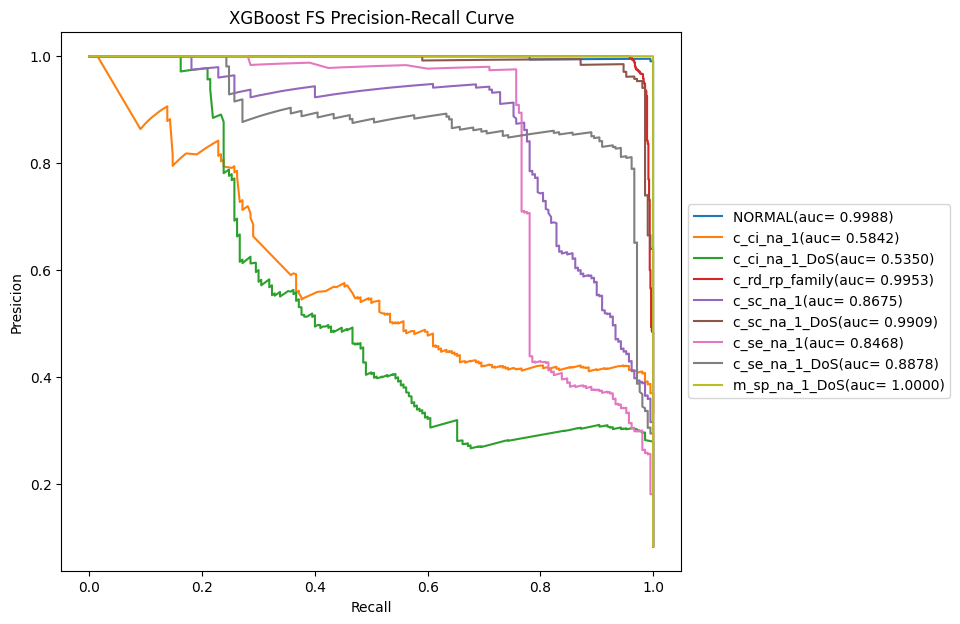

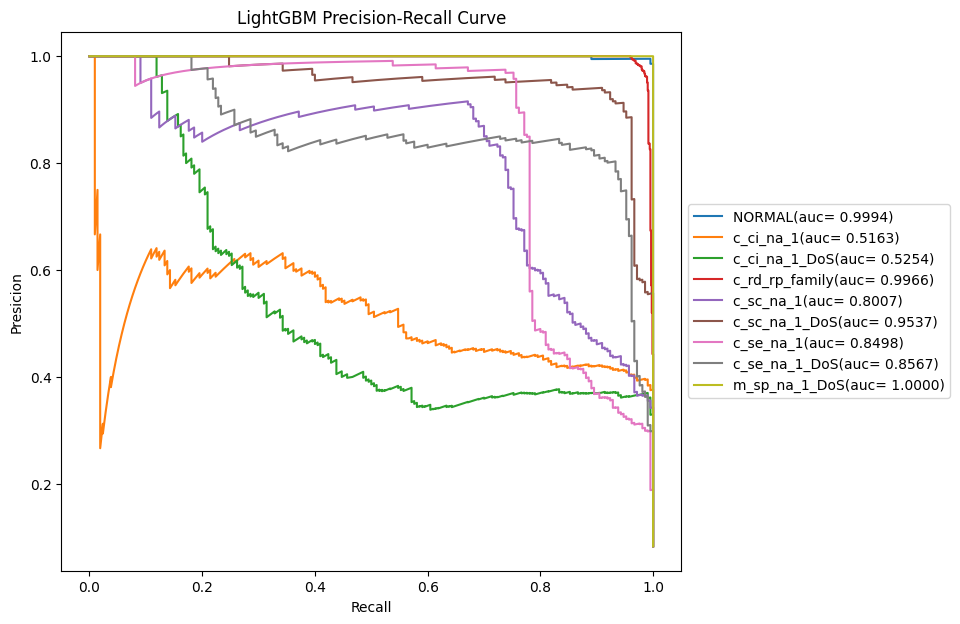

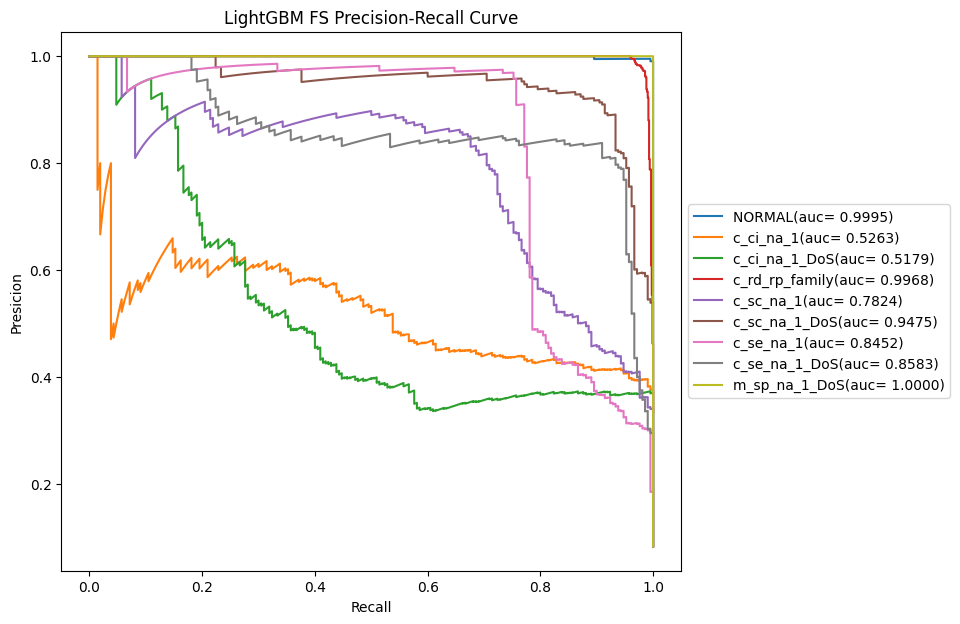

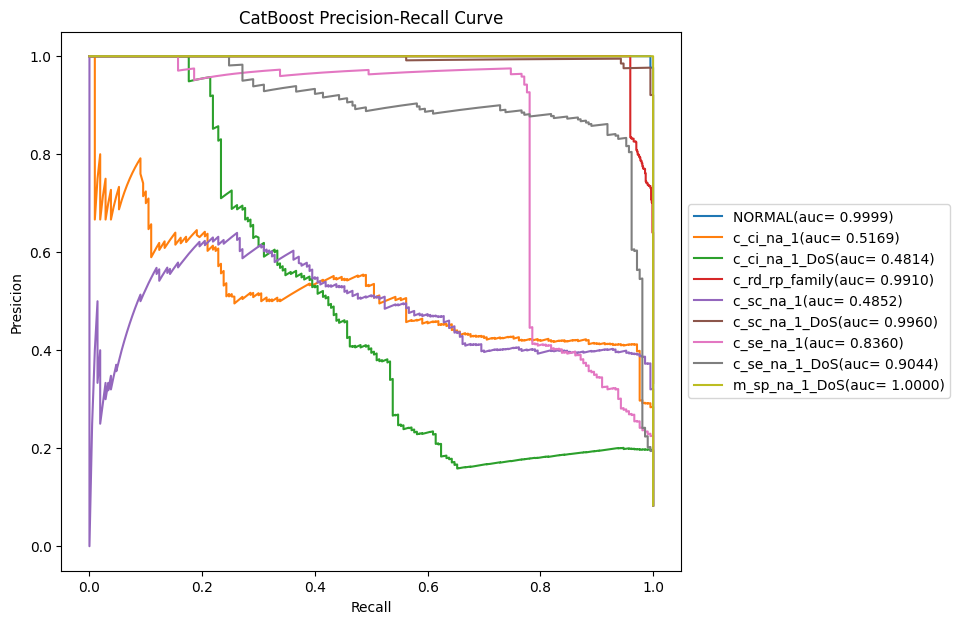

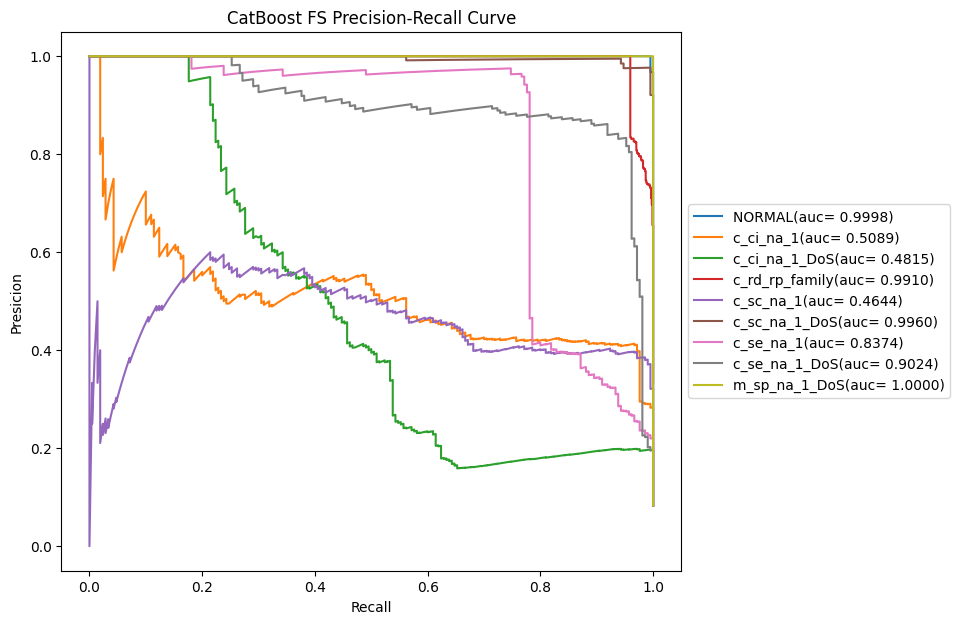

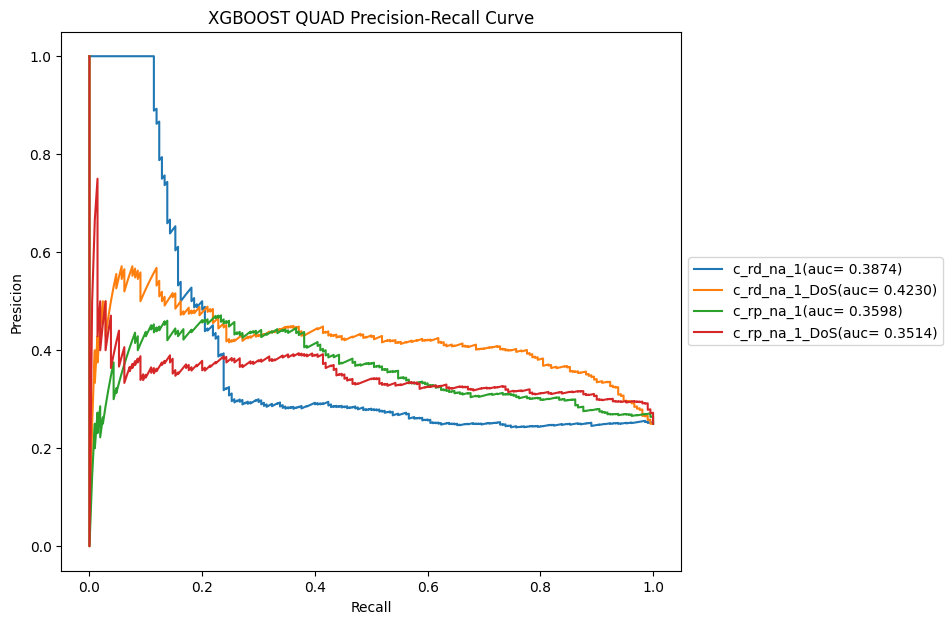

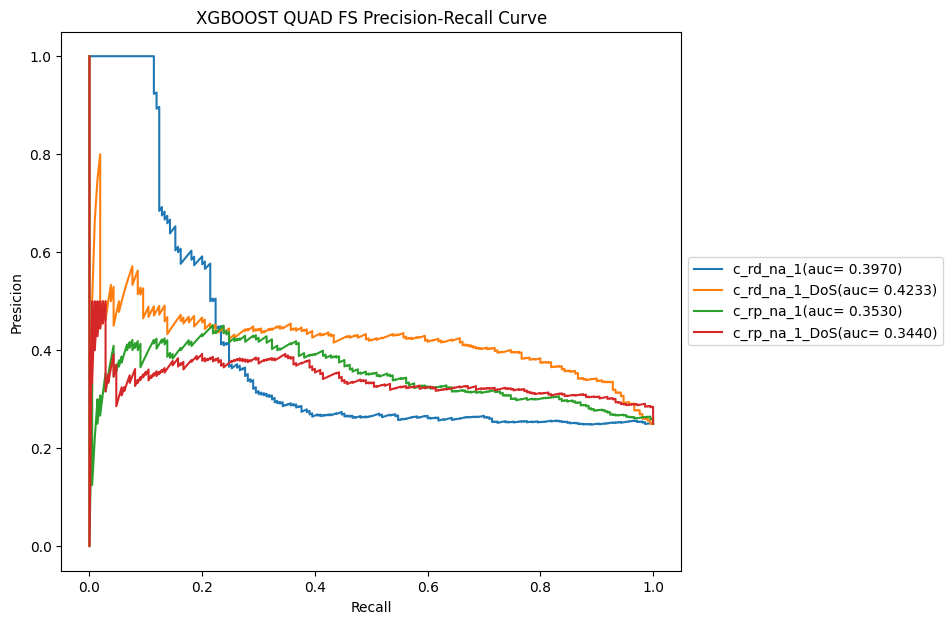

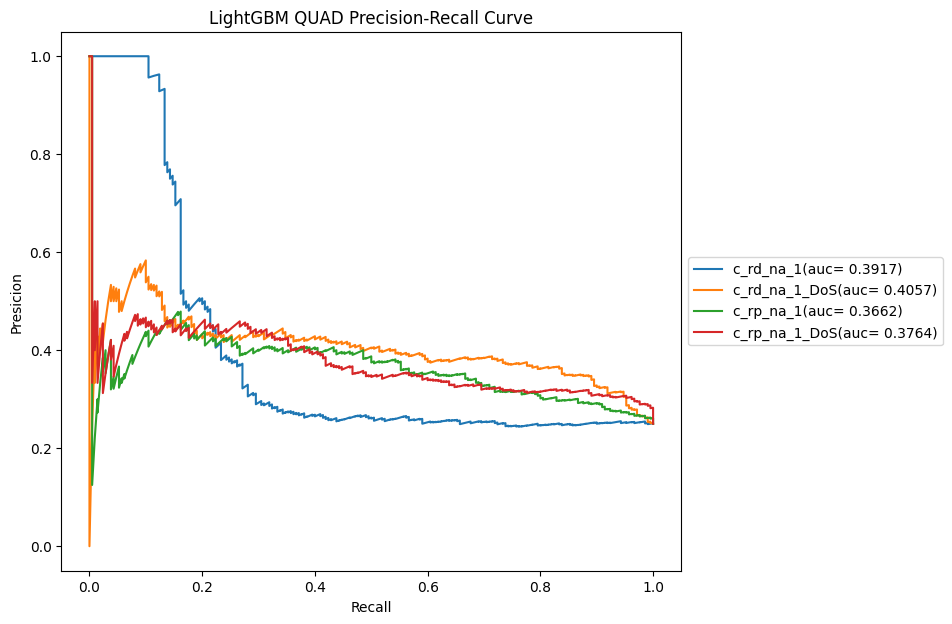

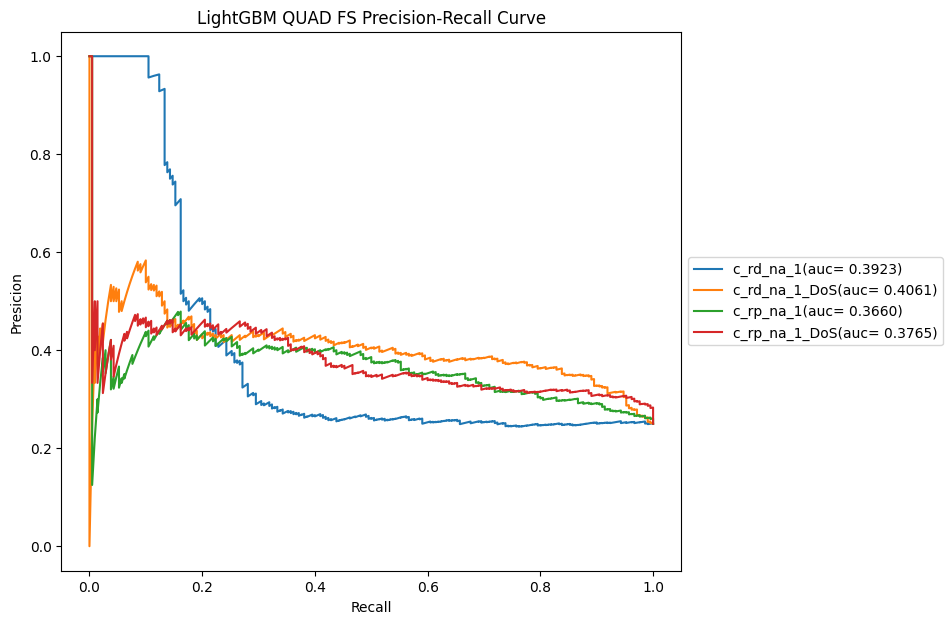

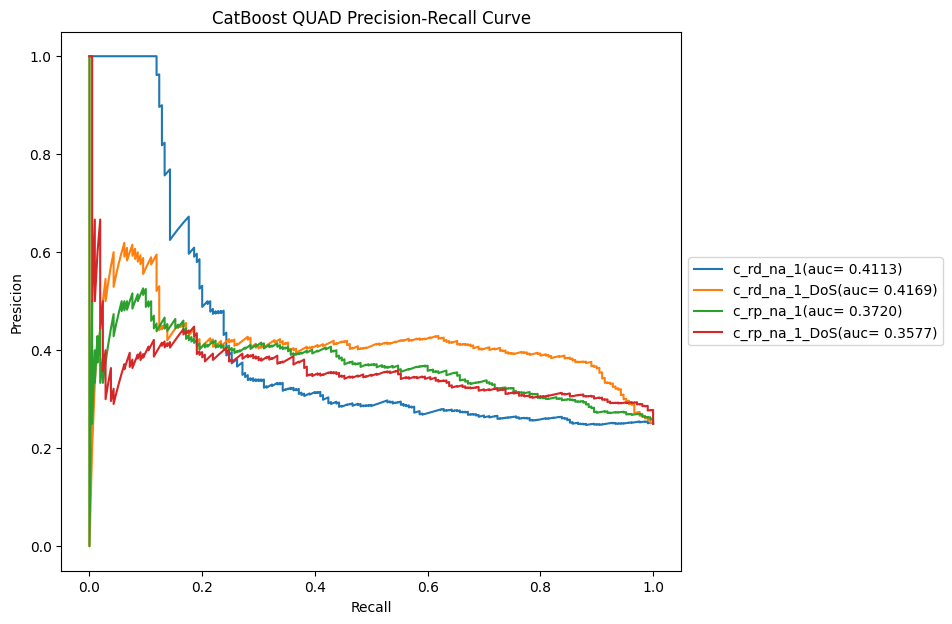

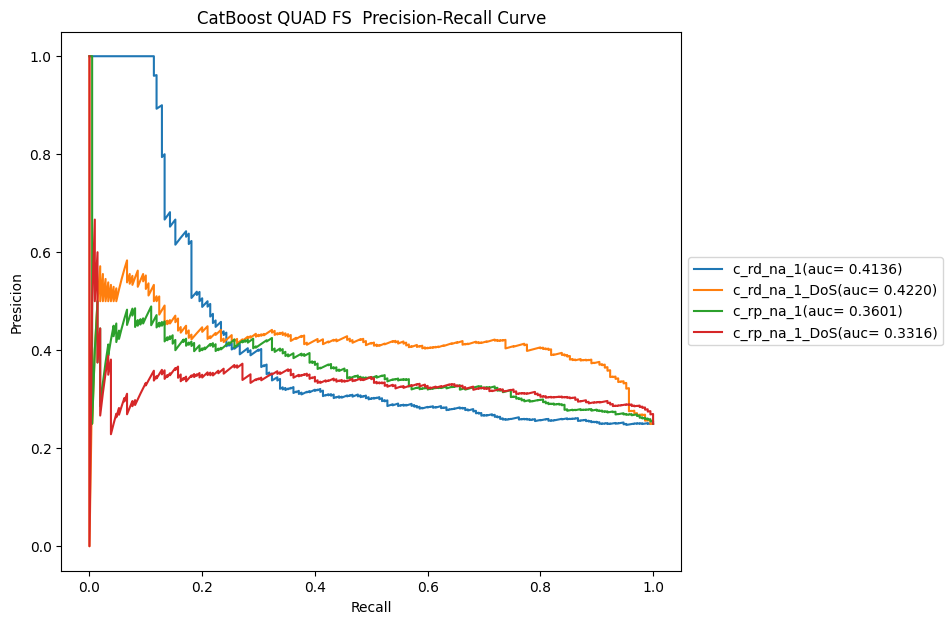

In [19]:
def pr_auc(model,X,title):
    if "QUAD" in title:
        return
    precision={}
    recall={}
    model_avg_pr_score={}
    model_y_pred_proba=model.predict_proba(X)
    for i in range(class_range):
        precision[i],recall[i],_=precision_recall_curve(Binarized_labels[:,i],model_y_pred_proba[:,i])
        model_avg_pr_score[i]=average_precision_score(Binarized_labels[:,i],model_y_pred_proba[:,i])
    plt.figure(figsize=(8,7))
    for i in range(class_range):
        plt.plot(recall[i],precision[i],label=f'{le.classes_[i]}(auc= {model_avg_pr_score[i]:.4f})')
    plt.title(f'{title} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Presicion')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
    plt.show()
functions(pr_auc)

def pr_auc_quad(model,X,title):
    if "QUAD" not in title:
        return
    precision={}
    recall={}
    model_avg_pr_score={}
    model_y_pred_proba=model.predict_proba(X)
    for i in range(4):
        precision[i],recall[i],_=precision_recall_curve(Binarized_labels_quad[:,i],model_y_pred_proba[:,i])
        model_avg_pr_score[i]=average_precision_score(Binarized_labels_quad[:,i],model_y_pred_proba[:,i])
    plt.figure(figsize=(8,7))
    for i in range(4):
        plt.plot(recall[i],precision[i],label=f'{le_quad.classes_[i]}(auc= {model_avg_pr_score[i]:.4f})')
    plt.title(f'{title} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Presicion')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
    plt.show()
functions(pr_auc_quad)

# PR-AUC

### The RFECV XGB model performs very well on normal (0.99), c_rd_rp_family (0.9953), c_sc_na_1 (0.8675), c_sc_na_1_DoS (0.99), c_se_na_1 (0.84), c_se_na_1_DoS (0.88) and m_sp_na_1_DoS (1.00). The weakest are c_ci_na_1 and c_ci_na_1_DoS, near 0.5.

### The quad RFECV XGB model scores very low, with every class around ~0.37 — the model is drowning in false positives and false negatives for these classes.

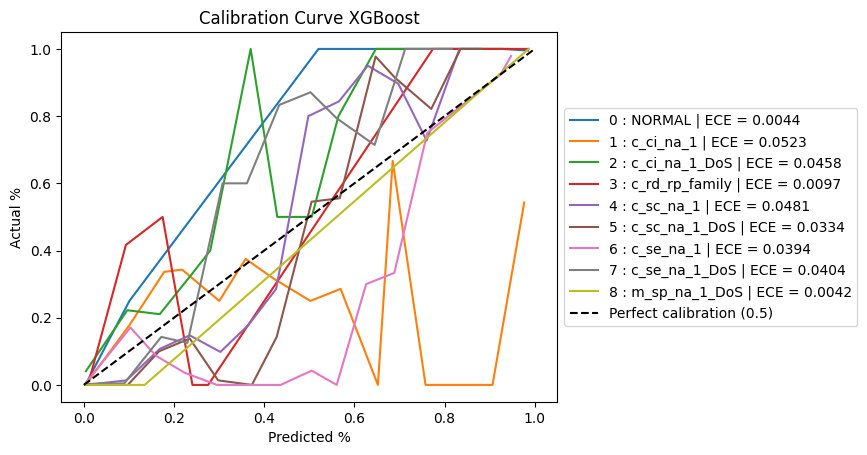

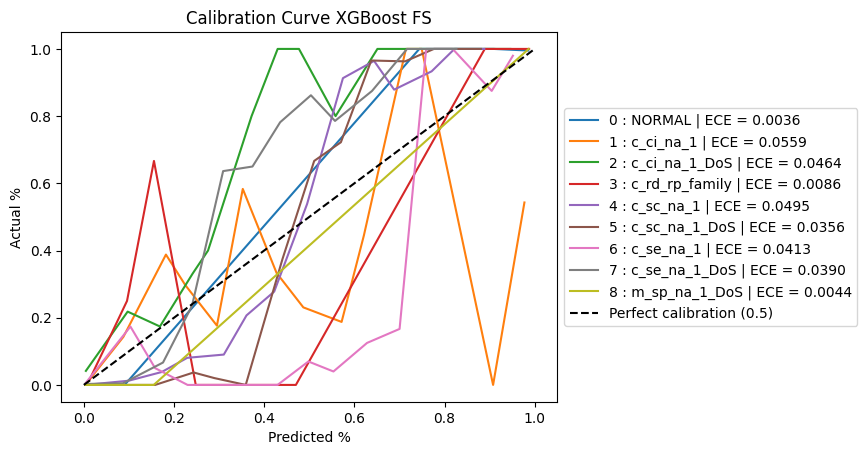

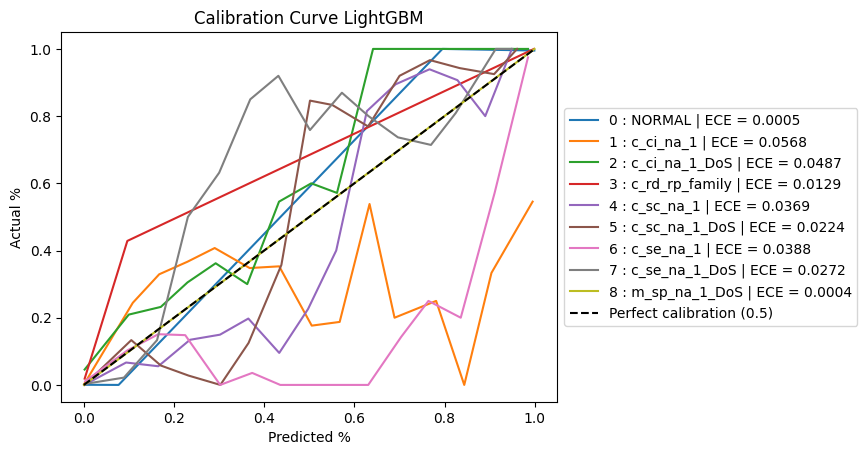

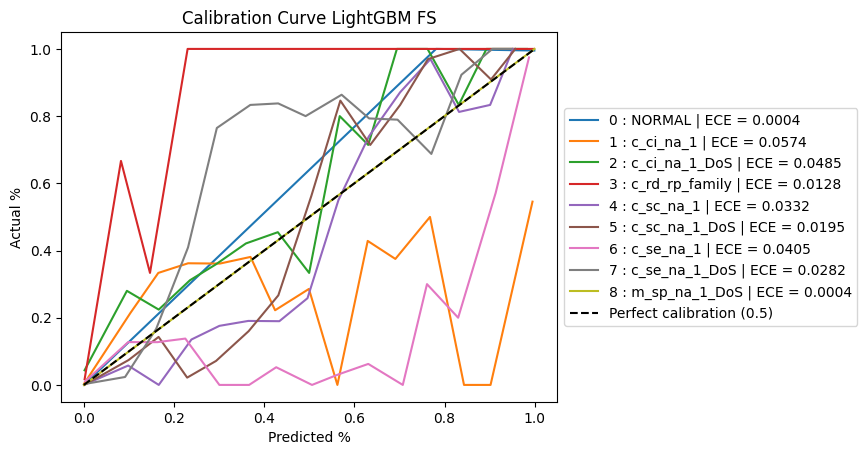

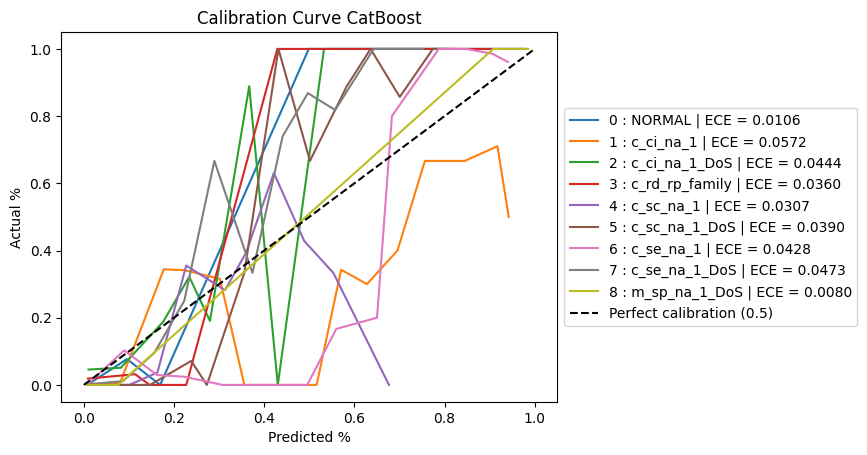

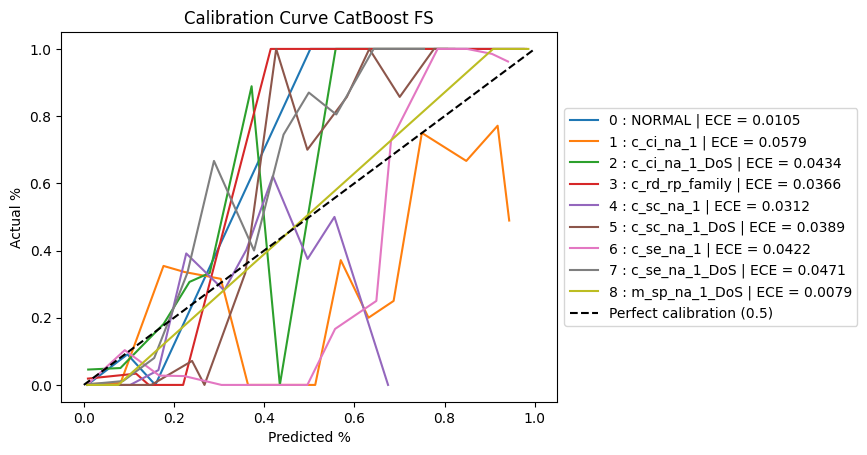

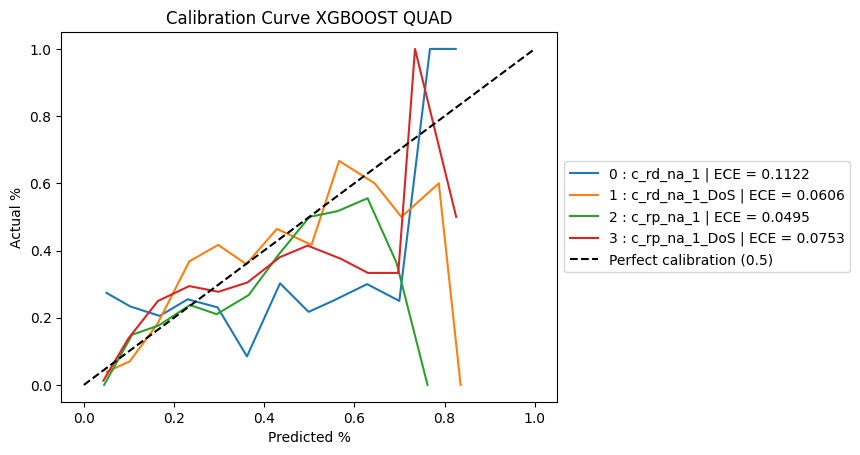

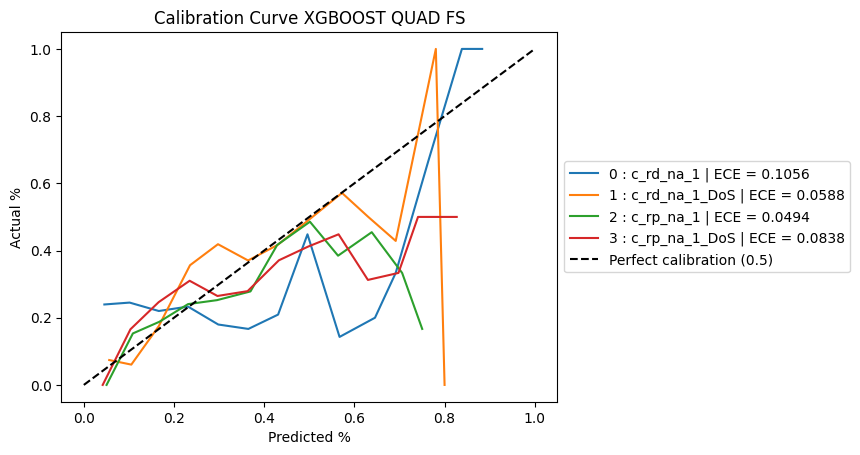

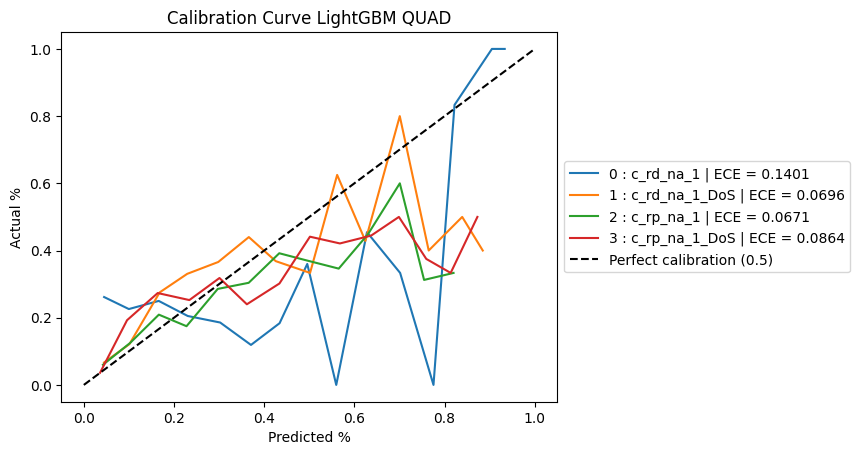

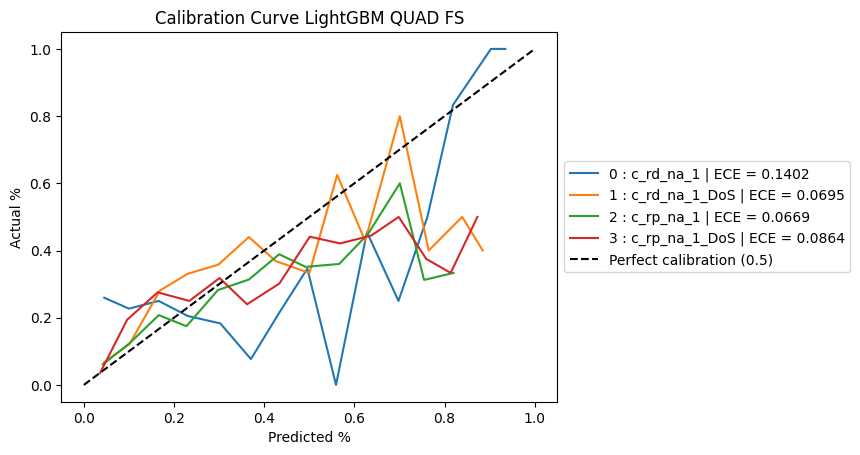

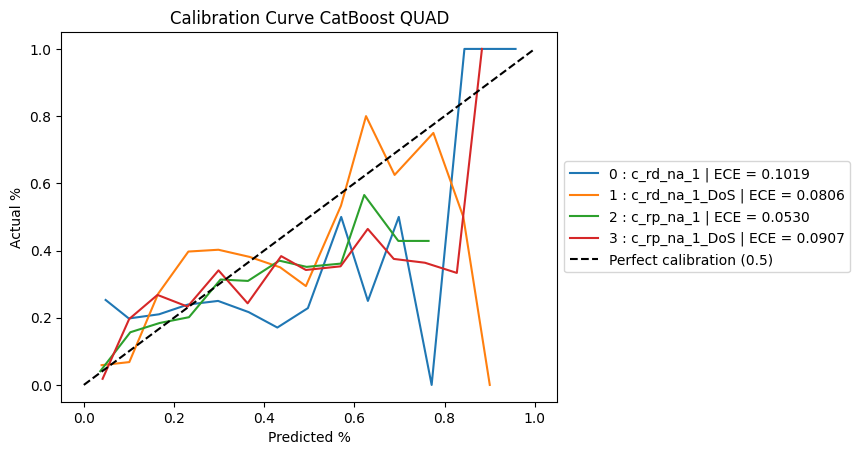

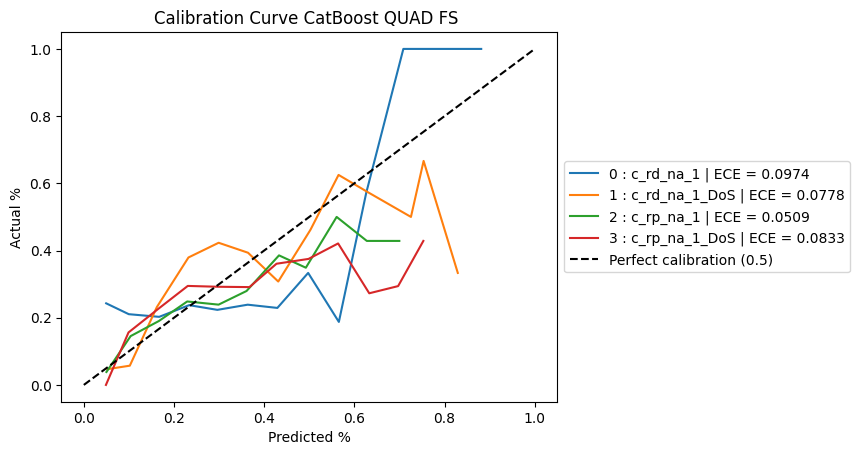

In [20]:

def Calibration_curve_models(model,X,title):
    if "QUAD" in title:
        return
    bins=15
    for c in range(class_range):
        model_y_pred_proba=model.predict_proba(X)
        prob_true,prob_pred=calibration_curve(Binarized_labels[:,c],model_y_pred_proba[:,c],n_bins=bins)
        bin_total,_=np.histogram(model_y_pred_proba[:,c],bins=bins,range=(0,1))
        non_zero_bins=bin_total>0
        weights_for_each_bin=bin_total[non_zero_bins]/len(y_test)
        diff=np.abs(prob_true-prob_pred)
        ece=np.sum(diff*weights_for_each_bin)
        plt.plot(prob_pred,prob_true,label=f'{c} : {le.classes_[c]} | ECE = {ece:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration (0.5)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('Predicted %')
    plt.ylabel('Actual %')
    plt.title(f'Calibration Curve {title}')
    plt.show()
functions(Calibration_curve_models)

def Calibration_curve_models_quad(model,X,title):
    if "QUAD" not in title:
        return
    bins=15
    for c in range(4):
        model_y_pred_proba=model.predict_proba(X)
        prob_true,prob_pred=calibration_curve(Binarized_labels_quad[:,c],model_y_pred_proba[:,c],n_bins=bins)
        bin_total,_=np.histogram(model_y_pred_proba[:,c],bins=bins,range=(0,1))
        non_zero_bins=bin_total>0
        weights_for_each_bin=bin_total[non_zero_bins]/len(y_test_quad)
        diff=np.abs(prob_true-prob_pred)
        ece=np.sum(diff*weights_for_each_bin)
        plt.plot(prob_pred,prob_true,label=f'{c} : {le_quad.classes_[c]} | ECE = {ece:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration (0.5)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('Predicted %')
    plt.ylabel('Actual %')
    plt.title(f'Calibration Curve {title}')
    plt.show()
functions(Calibration_curve_models_quad)


# Calibration curves
## on the XGBOOST model
### The full-class models underestimate the DoS variants in parts of the curve and overestimate their normal counterparts.
### In the quad model, c_rd_na_1_DoS is the most underestimated class and c_rd_na_1 the most overestimated; c_rp_na_1 and c_rp_na_1_DoS behave the same way.


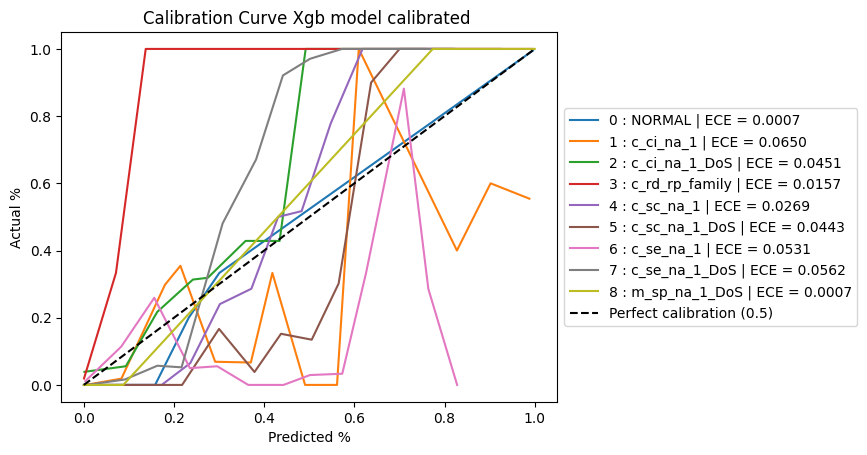

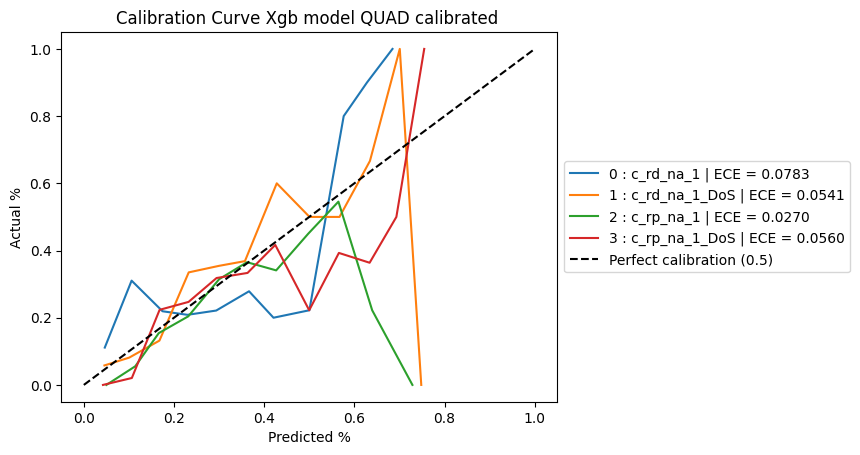

In [21]:
calibrated_Xgb=CalibratedClassifierCV(
        estimator=clone(Xgb_model),
        method='isotonic',
        cv=3,
)
calibrated_Xgb.fit(X_train,y_train)
Calibration_curve_models(calibrated_Xgb,X_test,'Xgb model calibrated ')


calibrated_Xgb_quad=CalibratedClassifierCV(
        estimator=clone(Xgb_model_quad),
        method='isotonic',
        cv=3,
)
calibrated_Xgb_quad.fit(X_train_quad,y_train_quad)
Calibration_curve_models_quad(calibrated_Xgb_quad,X_test_quad,'Xgb model QUAD calibrated ')

# For the full-class calibrated XGB model wee see no improvement which means that the model is already well calibrated and it can't do much more, more features are needed to improve the model
### Quad model — calibration helps ECE but not the real problem. Here isotonic calibration improved ECE across all four classes (c_rd_na_1 0.1122 → 0.0783, c_rd_na_1_DoS 0.0606 → 0.0541, c_rp_na_1 0.0495 → 0.0270, c_rp_na_1_DoS 0.0753 → 0.0560), so the raw probabilities were genuinely miscalibrated. The features do not separate c_rd from c_rp, and no amount of calibration can fix that.


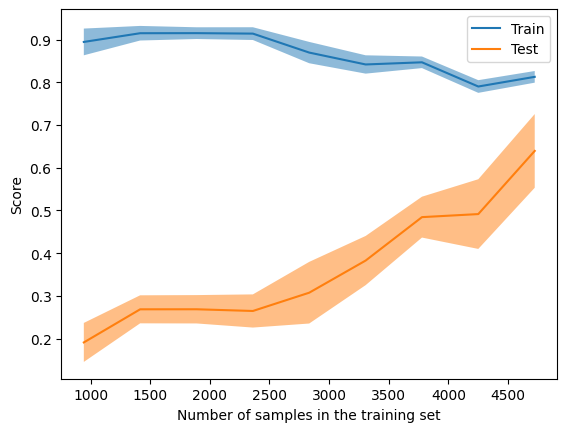

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    Xgb_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro',                    
    n_jobs=-1                              
)
display=LearningCurveDisplay(train_sizes=train_sizes,train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()

From the learning curve we understand that the model as the number of samples progresses it improves its accuracy so that means that more data maybe could help the model 

In [25]:
reducer=umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
scaler=StandardScaler()
Scaled_data=scaler.fit_transform(X_data)
embeding=reducer.fit_transform(Scaled_data)


c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
quad_reducer=umap.UMAP(n_neighbors=30,min_dist=0.1,random_state=42)
scaled_data_quad=scaler.fit_transform(X_data_quad)
embeding_quad=quad_reducer.fit_transform(scaled_data_quad)

c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


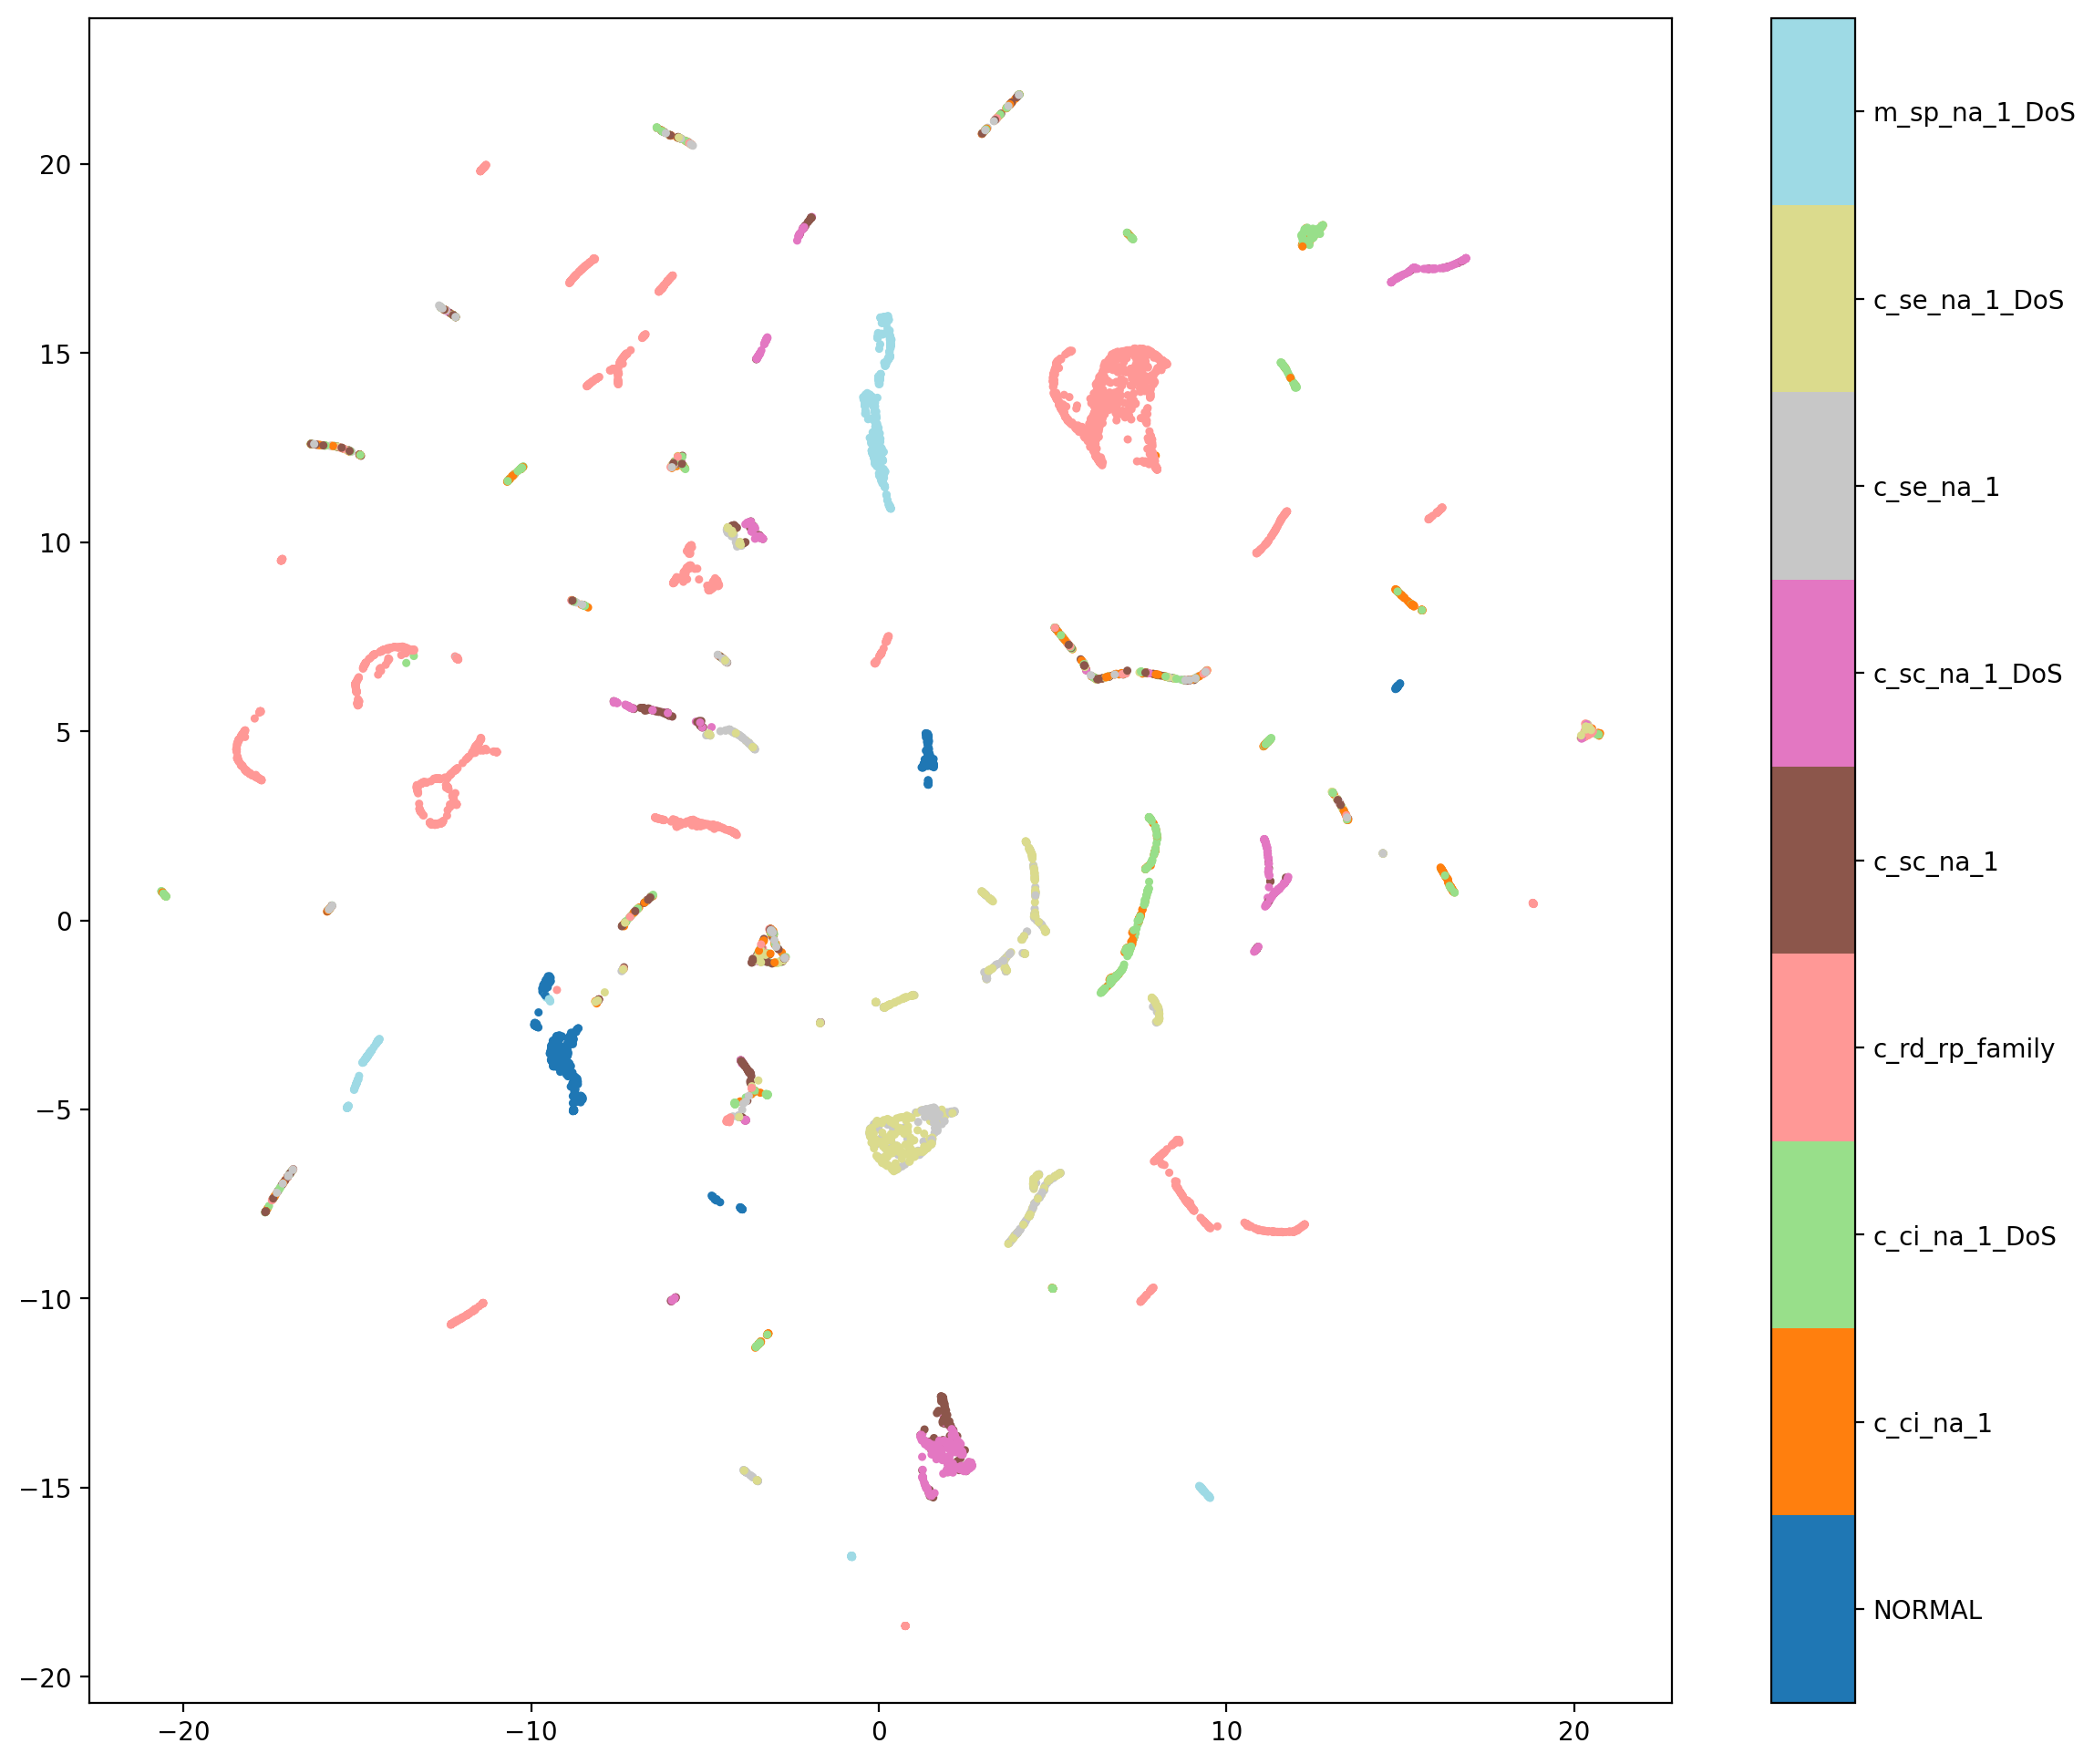

In [32]:
plt.figure(figsize=(14,12),dpi=200)
sc=plt.scatter(embeding[:,0],embeding[:,1],c=y_data,cmap='tab20',s=5,alpha=1)
cbar = plt.colorbar(sc, boundaries=np.arange(class_range + 1) - 0.5)
cbar.set_ticks(np.arange(class_range))
cbar.set_ticklabels(le.classes_)
plt.show()

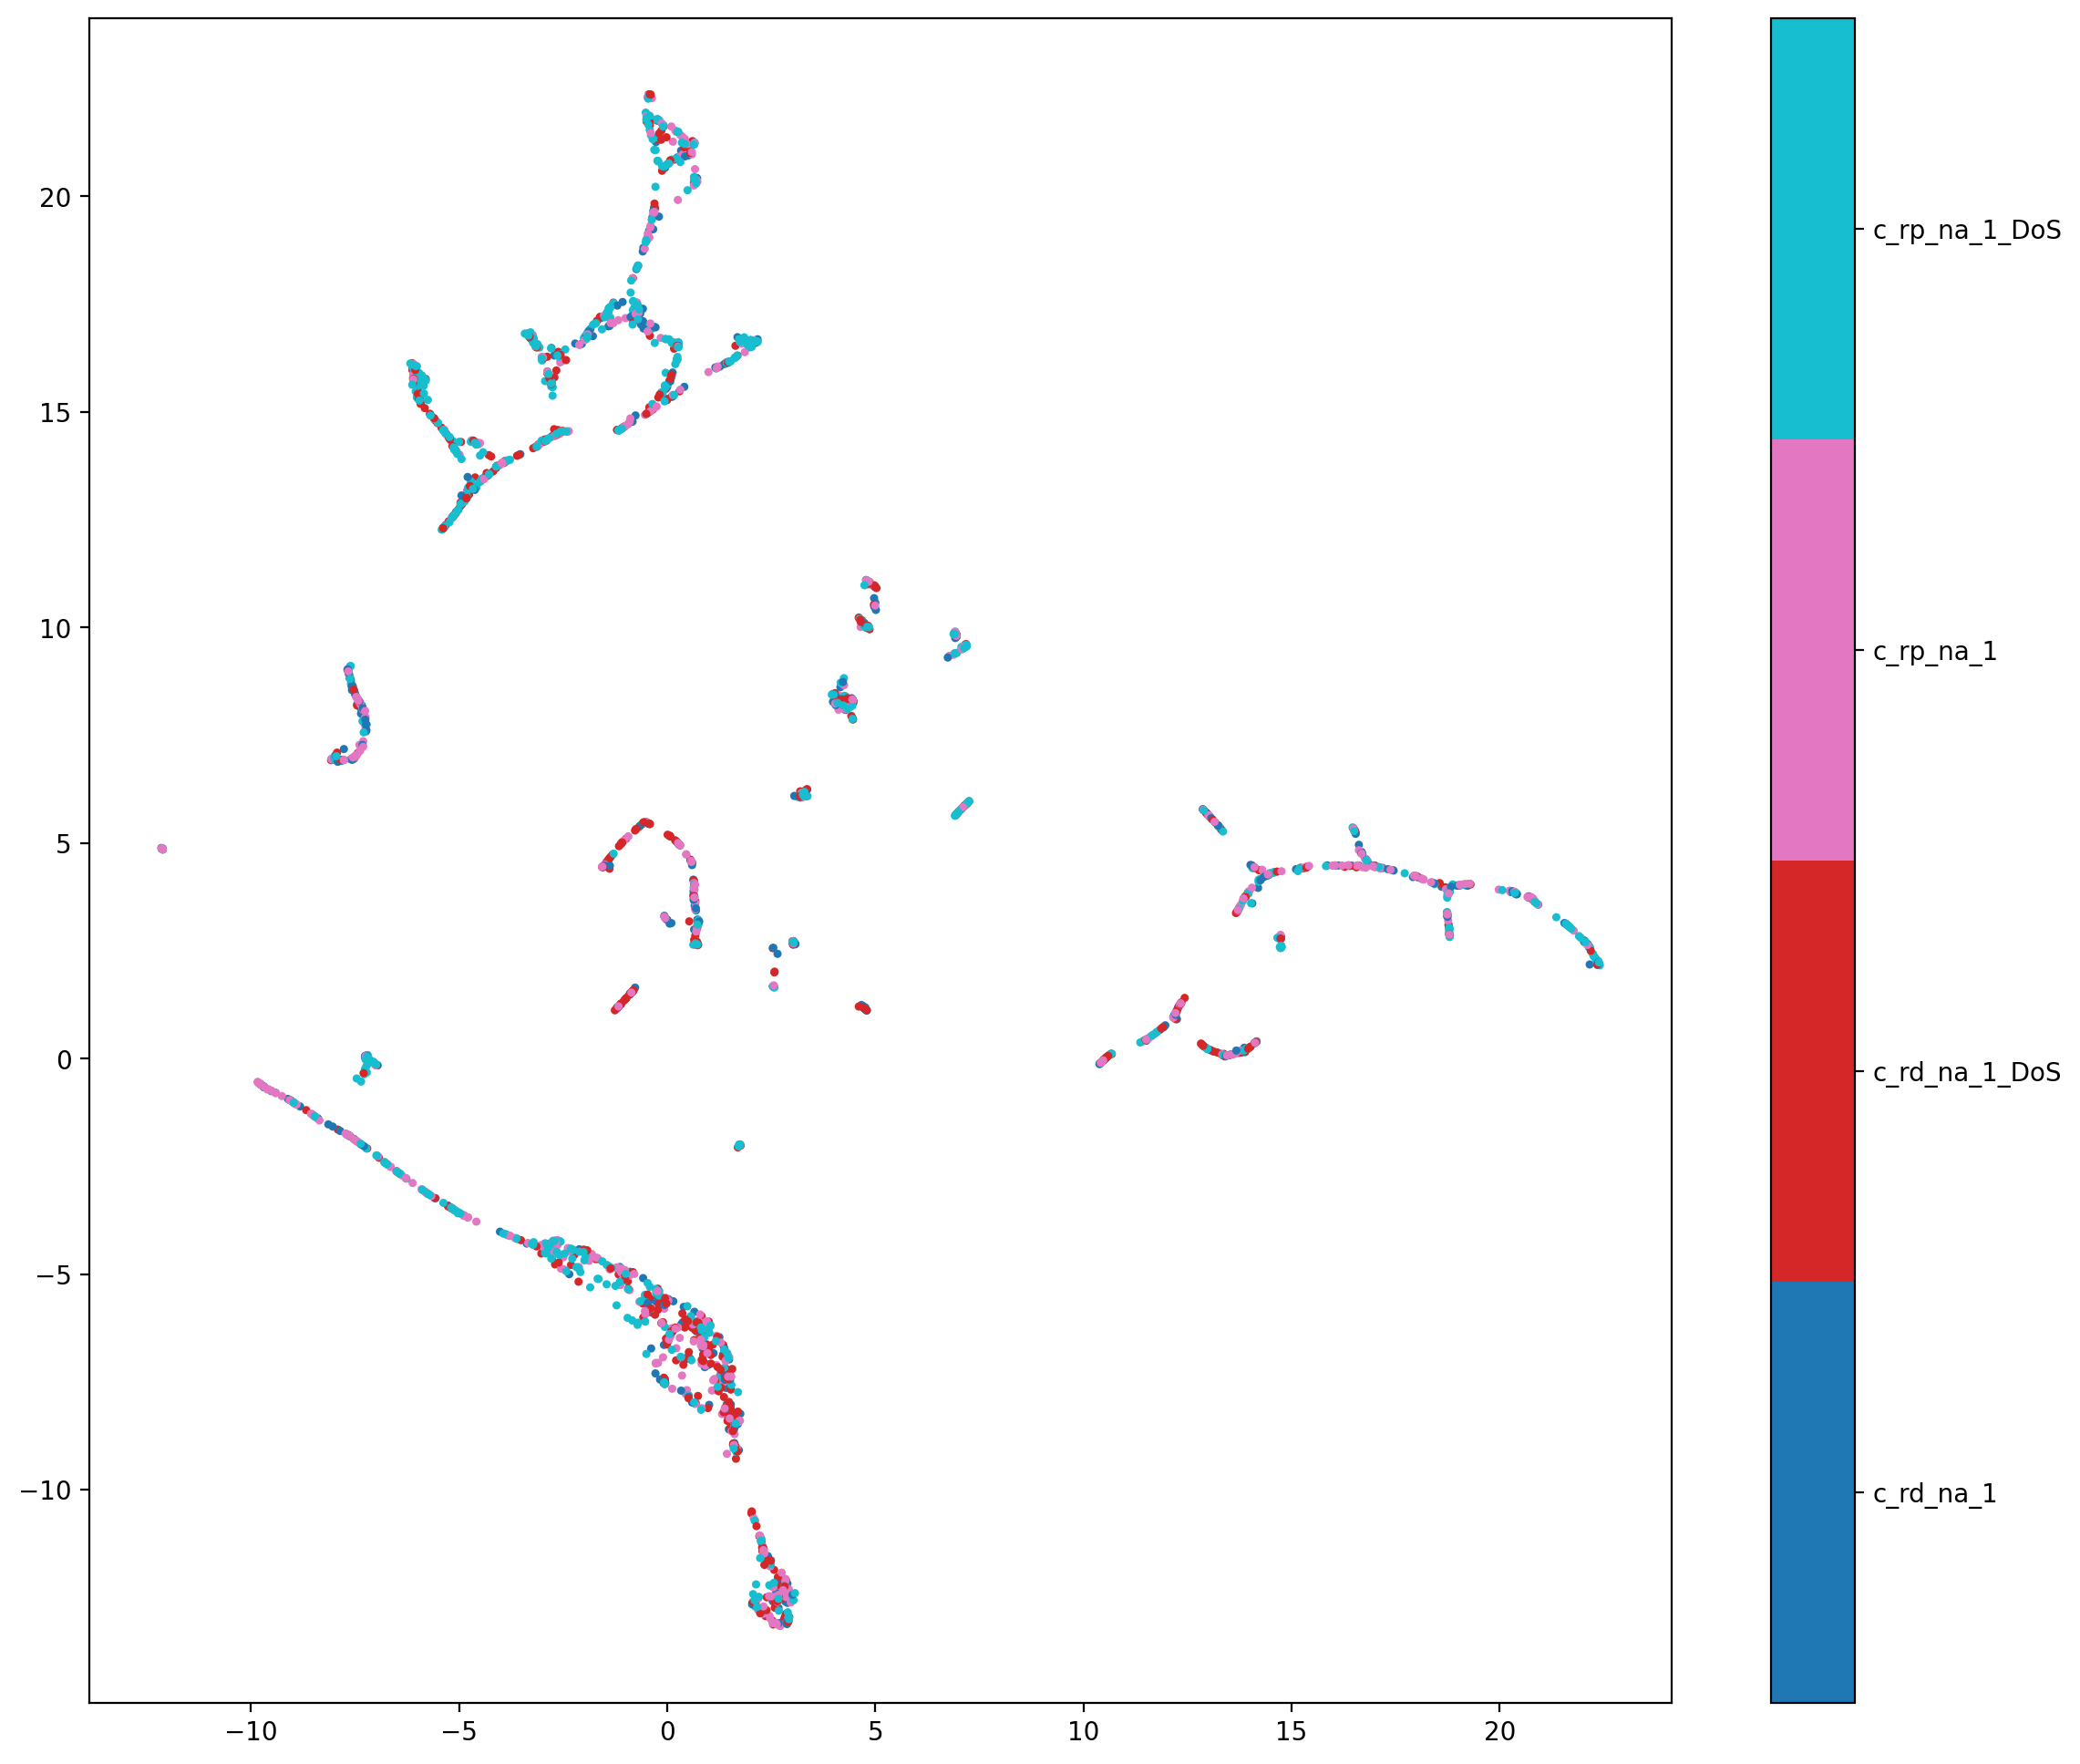

In [33]:
plt.figure(figsize=(14,12),dpi=200)
sc=plt.scatter(embeding_quad[:,0],embeding_quad[:,1],c=y_data_quad,cmap='tab10',s=5,alpha=1)
cbar = plt.colorbar(sc, boundaries=np.arange(4+ 1) - 0.5)
cbar.set_ticks(np.arange(4))
cbar.set_ticklabels(le_quad.classes_)
plt.show()

# UMAP

### In the UMAP projection of the full feature space, every class overlaps with its own DoS counterpart — normal and DoS variants of the same command land in the same regions. The most merged and least separated pair is c_ci_na_1 and its DoS version.

### For the quad family, the four classes (c_rd_na_1, c_rp_na_1 and their DoS variants) sit together throughout the projection, confirming that their features have very similar values.

In [35]:
def run_models(model,X,title):
    print(f"{title} classification report: \n")
    y_pred=model.predict(X)
    if 'QUAD' in title:
        print(classification_report(y_test_quad,y_pred))
    else:
        print(classification_report(y_test,y_pred))
functions(run_models)


XGBoost classification report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       0.48      0.61      0.54       210
           2       0.80      0.18      0.29       210
           3       1.00      0.96      0.98       840
           4       0.51      0.86      0.64       210
           5       0.91      0.96      0.93       210
           6       0.68      0.78      0.73       210
           7       0.81      0.63      0.71       210
           8       1.00      1.00      1.00       210

    accuracy                           0.82      2520
   macro avg       0.80      0.77      0.76      2520
weighted avg       0.85      0.82      0.81      2520

XGBoost FS classification report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       0.49      0.60      0.54       210
           2       0.95      0.18      0.30       210
         

In [36]:
y_pred_first=Xgb_model.predict(X_test)
mask=y_pred_first==3
clear_testDf = pd.read_csv('test_60_custom_script.csv')
y_routed_label=clear_testDf.loc[mask,'Label']
valid=y_routed_label.isin(le_quad.classes_)
X_test_clear=X_test.loc[mask,X_test.columns]
final_prediction=rfecv_Xgb_quad.predict(X_test_clear)
final_prediction_labeled=le_quad.inverse_transform(final_prediction)
print(classification_report(y_routed_label[valid],final_prediction_labeled[valid]))

               precision    recall  f1-score   support

    c_rd_na_1       0.24      0.19      0.21       181
c_rd_na_1_DoS       0.46      0.32      0.38       204
    c_rp_na_1       0.36      0.45      0.40       210
c_rp_na_1_DoS       0.37      0.45      0.41       210

     accuracy                           0.36       805
    macro avg       0.36      0.35      0.35       805
 weighted avg       0.36      0.36      0.35       805



In [37]:
untouched_trainDf=pd.read_csv('train_60_custom_script.csv')
untouched_testDf=pd.read_csv('test_60_custom_script.csv')
le_un=LabelEncoder()
le_un.fit(untouched_trainDf['Label'])
X_train_un=untouched_trainDf.drop('Label',axis=1)
y_train_un=le_un.transform(untouched_trainDf['Label'])
X_test_un=untouched_testDf.drop('Label',axis=1)
y_test_un=le_un.transform(untouched_testDf['Label'])

new_xgb=XGBClassifier(
    max_depth=4,
    n_estimators=100,
    learning_rate=0.05,
    random_state=63  
)
new_xgb.fit(X_train_un,y_train_un)
new_xgb_predict=new_xgb.predict(X_test_un)
print(classification_report(y_test_un,new_xgb_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       0.47      0.60      0.53       210
           2       0.86      0.18      0.30       210
           3       0.18      0.13      0.15       210
           4       0.49      0.21      0.29       210
           5       0.33      0.44      0.38       210
           6       0.36      0.50      0.42       210
           7       0.47      0.76      0.58       210
           8       0.83      0.95      0.89       210
           9       0.68      0.78      0.73       210
          10       0.80      0.62      0.70       210
          11       1.00      1.00      1.00       210

    accuracy                           0.60      2520
   macro avg       0.62      0.60      0.58      2520
weighted avg       0.62      0.60      0.58      2520

